# 02 Exploratory Data Analysis (EDA)

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

import sys
from pathlib import Path

SRC_PATH = Path.cwd().parent / "src"
sys.path.append(str(SRC_PATH))

## 1. Data Loading

### 1.1 Read review_analysis.db database

In [2]:
# Connect to the database
conn = sqlite3.connect("../data/reviews_analysis.db")

# Read all table in the database
hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

* Convert to pandas dataframe

In [3]:
# Print our table name
tables = hotels_df['name'].tolist()
tables

['reviews', 'authors', 'hotels']

In total we have 3 tables:
1. Reviews
2. Authors
3. Hotels

### Save dataset as dictionary

In [4]:
# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

In [5]:
# Print dictionary keys to ensure the tables are in
dataset.keys()

dict_keys(['reviews', 'authors', 'hotels'])

In [6]:
# Print every column and data type for each table
for table in dataset.keys():
    print(f'\nTable name:   {table}')
    print(f'{dataset[table].dtypes}')


Table name:   reviews
title                       object
text                        object
date_stayed                 object
hotel_id                    object
num_helpful_votes            int64
review_date                 object
review_id                   object
via_mobile                   int64
service_rating             float64
cleanliness_rating         float64
overall_rating             float64
value_rating               float64
location_rating            float64
sleep_quality_rating       float64
rooms_rating               float64
check_in_service_rating    float64
business_service_rating    float64
author_id                   object
dtype: object

Table name:   authors
id                    object
username              object
num_cities           float64
num_helpful_votes    float64
num_reviews          float64
num_type_reviews     float64
location              object
alias                 object
dtype: object

Table name:   hotels
hotel_id                             objec

Most of the features name and data dtype looks correct except for the date. So the following code is to cast the date to pandas datetime.

### Converting dates to datetime

In [7]:
# Convert 'date_stayed' to datetime
dataset['reviews']['date_stayed'] = pd.to_datetime(
    dataset['reviews']['date_stayed'],
    errors='coerce'
)

# Convert 'review_date' to datetime
dataset['reviews']['review_date'] = pd.to_datetime(
    dataset['reviews']['review_date'],
    errors='coerce'
)

In [8]:
# Show
dataset['reviews']['date_stayed'].isna().sum()

0

### Quick check for data validity

At some point, we might have irrelevant data where the date_stayed of the user is empty, in this case we can just drop it even if the data is not nan just for safety reason.

In [9]:
# Remove NaN entry from the reviews if the date_stayed is empty
dataset['reviews'].dropna(subset='date_stayed', inplace=True)

In [10]:
# Print
print(f"length of data after dropping: {len(dataset['reviews'])}")

length of data after dropping: 80000


If none of the data is deleted as seen above, then **the data is complete** in the first place.

### datetime data validity for relevancy

By checking the range of the date for review_date and stayed_date, we can validate data and increase data relevancy.

Rules:

Date is considered relevant if the day difference between review_date and the date_stayed is under 150 days.
This means that **the user review the hotel within 5 months** after their staying duration.

> **Why this step?** In our first iteration, there were some entries where the user review the hotel even 8 years after their staying duration.

In [11]:
reviews_df = dataset['reviews']

print(f"date_stayed date range:  {reviews_df['date_stayed'].min().strftime('%B %Y')} - {reviews_df['date_stayed'].max().strftime('%B %Y')}")
print(f"review_date date range:  {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}")

filtered = reviews_df[reviews_df['review_date'] - reviews_df['date_stayed'] <= pd.Timedelta(days=150)]
print(f'Count of valid data:     {len(filtered):,}')

date_stayed date range:  December 2007 - December 2012
review_date date range:  1 January 2008 - 20 December 2012
Count of valid data:     80,000


**What we have done so far:**
1. We have loaded all the tables in the dataset.
2. We have parse the datatype to the correct type for each column
3. We have done a quick check for data completeness and validity

---

## 2. Data Exploration

On this step, the column in the tables are valid, we can continue by exploring unique observations and findings from each table. During the process, we will also build some helpful features that might help us during the later steps.

### 2.1. Reviews table

In [12]:
reviews_df = dataset['reviews']
reviews_df.head()

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E


Now that the data date is valid and relevant, we can add new feature called 'review_days_since_stay' that denotes how long the review is given after the stay date.

#### 2.1.1. New columns: reviews_days_since_stay

We know that our user review their hotel within 5 months, but we don't have the exact day in the column and **our model will not be able to automatically derive this feature unless we define it**. So, let's create a new column called 'review_days_since_stay' the measures how many days do the user need until they finally leave a review.

In [13]:
# Create column reviews_days_since_stay
reviews_df['reviews_days_since_stay'] = reviews_df['review_date'] - reviews_df['date_stayed']
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


We start off with 1 helpful column, now we can start analyzing each column in the review table

#### 2.1.2. Analyze Columns

##### **Datetime**

In [14]:
# Analyse datetime columns
print('======== DATE ANALYSIS ========')
print(f"date_stayed date range:  {reviews_df['date_stayed'].min().strftime('%B %Y')} - {reviews_df['date_stayed'].max().strftime('%B %Y')}")
print(f"review_date date range:  {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}")

======== DATE ANALYSIS ========
date_stayed date range:  December 2007 - December 2012
review_date date range:  1 January 2008 - 20 December 2012


##### **Categorical**

In [15]:
# Categorical
print('======== CATEGORICAL ANALYSIS ========')
# Check the percentage of people with via_mobile = 1
print(f"{reviews_df['via_mobile'].mean():.2%} of people fill the review via mobile")

# Check the insight for each rating column
for col in ['service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']:
    
    print(f'\n- {col} average of all hotel is {reviews_df[col].mean():.1f} stars')                                # Average
    print(f'    - {(len(reviews_df[reviews_df[col] == 5]) / len(reviews_df)):.2%} of the rating is 5 stars')      # 5 stars rate
    print(f'    - {(len(reviews_df[reviews_df[col] == 1]) / len(reviews_df)):.2%} of the rating is 1 stars')      # 1 star rate
    
    # Count NaN entries
    nan_count = reviews_df[col].isna().sum()
    
    # Print percentage of NaN entries if exist
    if nan_count > 0:
        print(f'    - {(nan_count / len(reviews_df)):.2%} ({nan_count} entries) does not give any rating')

# Print the description of each column
reviews_df[['via_mobile','service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']].describe()

======== CATEGORICAL ANALYSIS ========
6.68% of people fill the review via mobile

- service_rating average of all hotel is 4.1 stars
    - 52.08% of the rating is 5 stars
    - 5.63% of the rating is 1 stars

- cleanliness_rating average of all hotel is 4.2 stars
    - 55.10% of the rating is 5 stars
    - 3.79% of the rating is 1 stars

- overall_rating average of all hotel is 4.0 stars
    - 41.82% of the rating is 5 stars
    - 5.14% of the rating is 1 stars

- value_rating average of all hotel is 3.9 stars
    - 40.79% of the rating is 5 stars
    - 5.86% of the rating is 1 stars

- location_rating average of all hotel is 4.4 stars
    - 62.04% of the rating is 5 stars
    - 1.60% of the rating is 1 stars

- sleep_quality_rating average of all hotel is 4.1 stars
    - 35.31% of the rating is 5 stars
    - 3.63% of the rating is 1 stars
    - 27.26% (21810 entries) does not give any rating

- rooms_rating average of all hotel is 4.0 stars
    - 40.73% of the rating is 5 stars
    -

,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,58190.000000,80000.000000,6337.00000,4315.000000
mean,0.066812,4.122675,4.249587,3.998413,3.930613,4.427613,4.100980,3.961125,4.01941,3.674160
std,0.249699,1.160277,1.047668,1.127664,1.167450,0.880480,1.121092,1.130975,1.19425,1.249188
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,0.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.00000,3.000000
50%,0.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.00000,4.000000
75%,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000


##### **Numerical**

In [16]:
# Numerical
print('======== NUMERICAL ANALYSIS ========')

reviews_df[['num_helpful_votes']].describe()

======== NUMERICAL ANALYSIS ========


,num_helpful_votes
count,80000.00000
mean,0.64005
std,1.25229
min,0.00000
25%,0.00000
50%,0.00000
75%,1.00000
max,103.00000


#### 2.1.3. Visualization

##### **Distribution of Reviews per Star Rating**

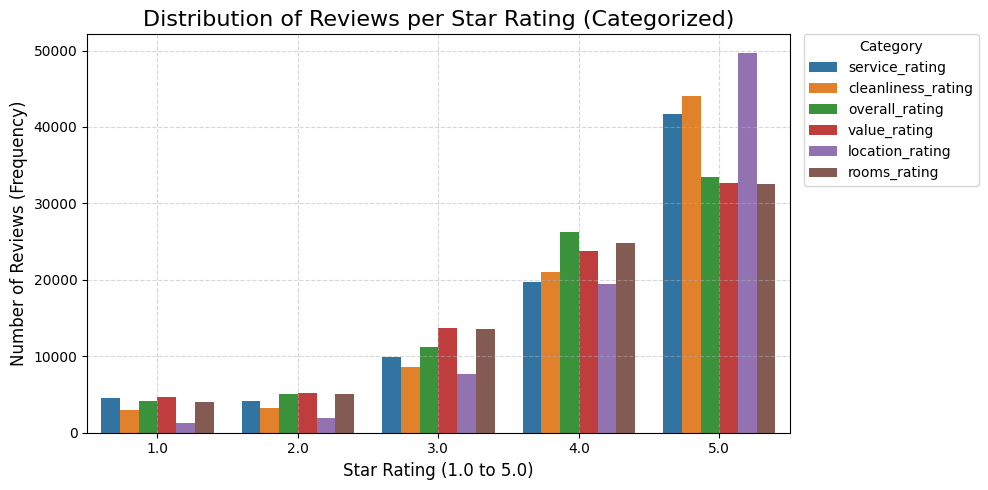

In [17]:
# Set which column will be used for count plot
# We exclude sleep quality rating, check_in_service_rating, business_service_rating because the metrics have low entry
review_num_cols = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','rooms_rating']

# The initial matplotlib script is generated with the help of Gemini AI
# https://gemini.google.com/share/d81a3d2d792b

# Melt by category and rating
df_melted = reviews_df[review_num_cols].melt(var_name="Category",value_name="Rating")

# Ensure Rating is treated as a categorical variable from 1 to 5 to show all bins
df_melted['Rating'] = pd.Categorical(df_melted['Rating'], categories=[1.0, 2.0, 3.0, 4.0, 5.0])

# Plotting
plt.figure(figsize=(10, 5))
sns.countplot(data=df_melted, x="Rating", hue="Category")

# Customizing labels
plt.title('Distribution of Reviews per Star Rating (Categorized)', fontsize=16)
plt.xlabel('Star Rating (1.0 to 5.0)', fontsize=12)
plt.ylabel('Number of Reviews (Frequency)', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()


Key observations (without considering check in rating and business service rating):

* **5 Stars** rating are mostly given due to **customer's satisfaction with location, cleanliness, and service**.
* **1 Star** rating are mostly given due to **customer's dissatisfaction with value, service, overall, and rooms rating**.
* **Feature wise**, location is the one that greatly satisfies the customer. Meanwhile, value and rooms are two features that has more diverse reviews which is probably due to higher subjective expectation.

This can be a good insight for a hotel to know which aspect they should prioritize for their business strength and strategy.


##### **Distribution of Reviews per Category**

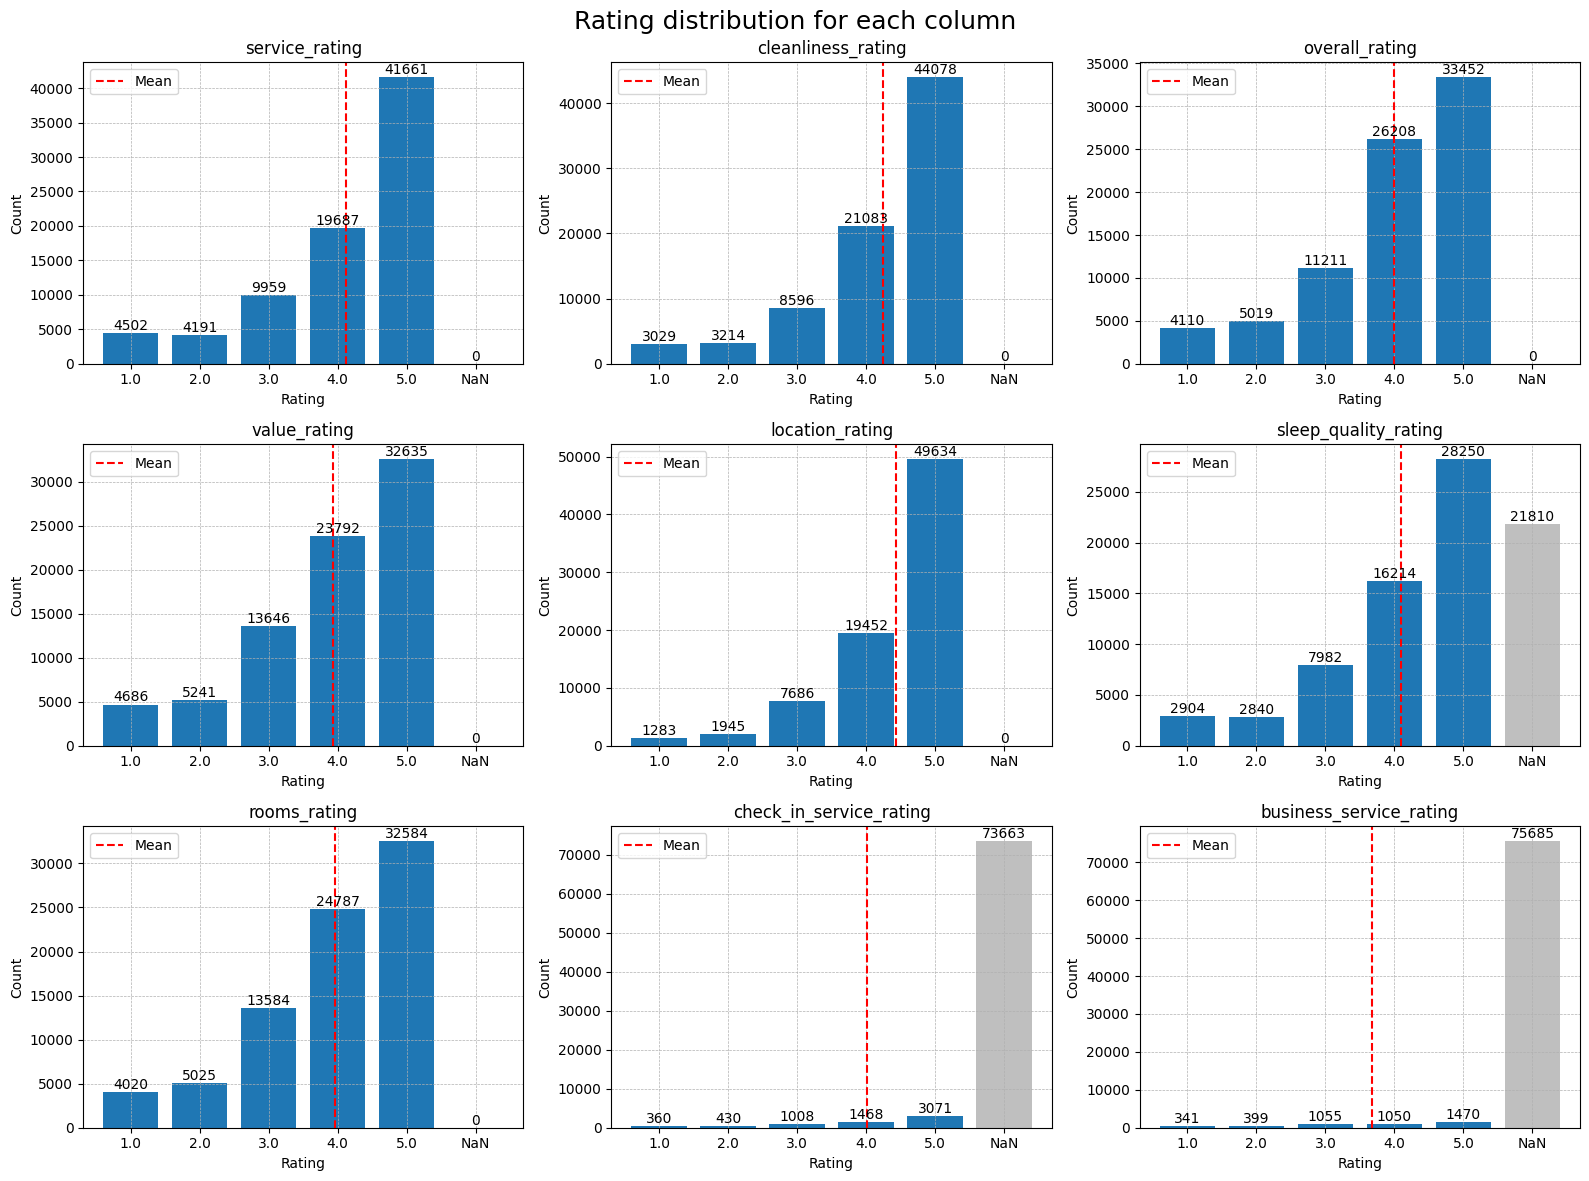

In [18]:
rating_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']

# Prepare subplot (3x3 for compactness)
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
ax = ax.flatten()

# Loop for each column
for i, col in enumerate(rating_column):
    
    # Get the mean for vertical line
    mean = reviews_df[col].mean()
    
    # Replace NaN with string "NaN"
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    
    # Do value_counts()
    counts = reviews_df_filled.value_counts()
    
    # Reindex so that we can show the NaN values as well
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']      # Set the color of the bar for each index
    
    # Plot the bar in the subplot
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to semi-transparent
    bars[-1].set_alpha(0.5)
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

Key Observations:
* **This confirms how location rating dominates** our dataset with the rating group seems left-skewed.
* On the other hand **value_rating still has the highest rate of 1-2 stars** among all features.

##### **Count for Number of Helpful Votes and Mobile Users**

/tmp/ipykernel_180938/1416910873.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(["False", "True"])


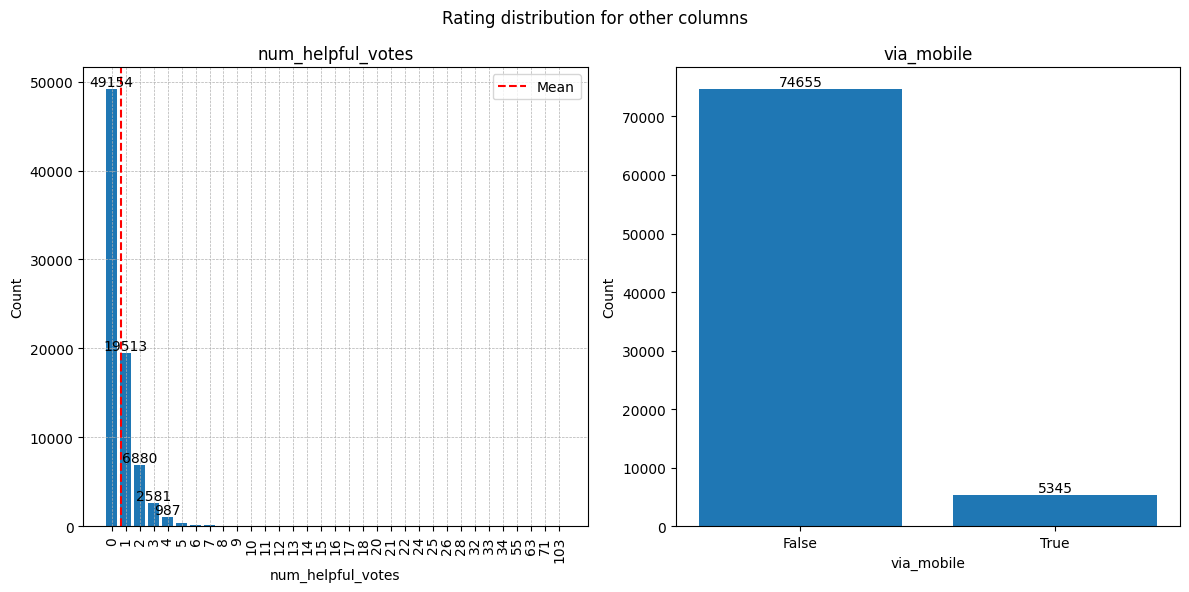

In [19]:
rating_column = ['num_helpful_votes', 'via_mobile',]

# Prepare subplots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax = ax.flatten()

# Repeat for every column
for i, col in enumerate(rating_column):
    
    # Get the mean for vertical line
    mean = reviews_df[col].mean()
    
    # Replace NaN with string "NaN"
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    
    # Do value_counts() and sort the index
    counts = reviews_df_filled.value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='coerce'))
    
    # Draw the bar chart
    bars = ax[i].bar(counts.index, counts.values)
    
    # Add counts on top of each bar (aligned to center of bar), hide insignificant value
    for bar in bars:
        
        height = bar.get_height()
        
        if height > 750:
            ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # For num_helpful_votes, we display a vertical line to show the mean, and add soft transparent grid
    if col == 'num_helpful_votes':
        ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        ax[i].grid(linestyle = '--', linewidth = 0.5)
        ax[i].tick_params(axis='x', rotation=90)
    
    # Print by string for better clarity
    if col == 'via_mobile':
        ax[i].set_xticklabels(["False", "True"])
    
    # Set title and label
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel(rating_column[i])
    ax[i].set_ylabel('Count')

# add main title and prevent overlapping
plt.suptitle('Rating distribution for other columns')
plt.tight_layout()
plt.show()

Key observations:
* **Most of the reviews are not helpful**, however there are many data points where about 1-4 people vote it as helpful.
* **There are several reviews with a higher rate of helpful votes**. However, the count is extremely insignificant.
* **6.68% people fill the review via mobile** which is very low

##### **Correlation matrix of the features**

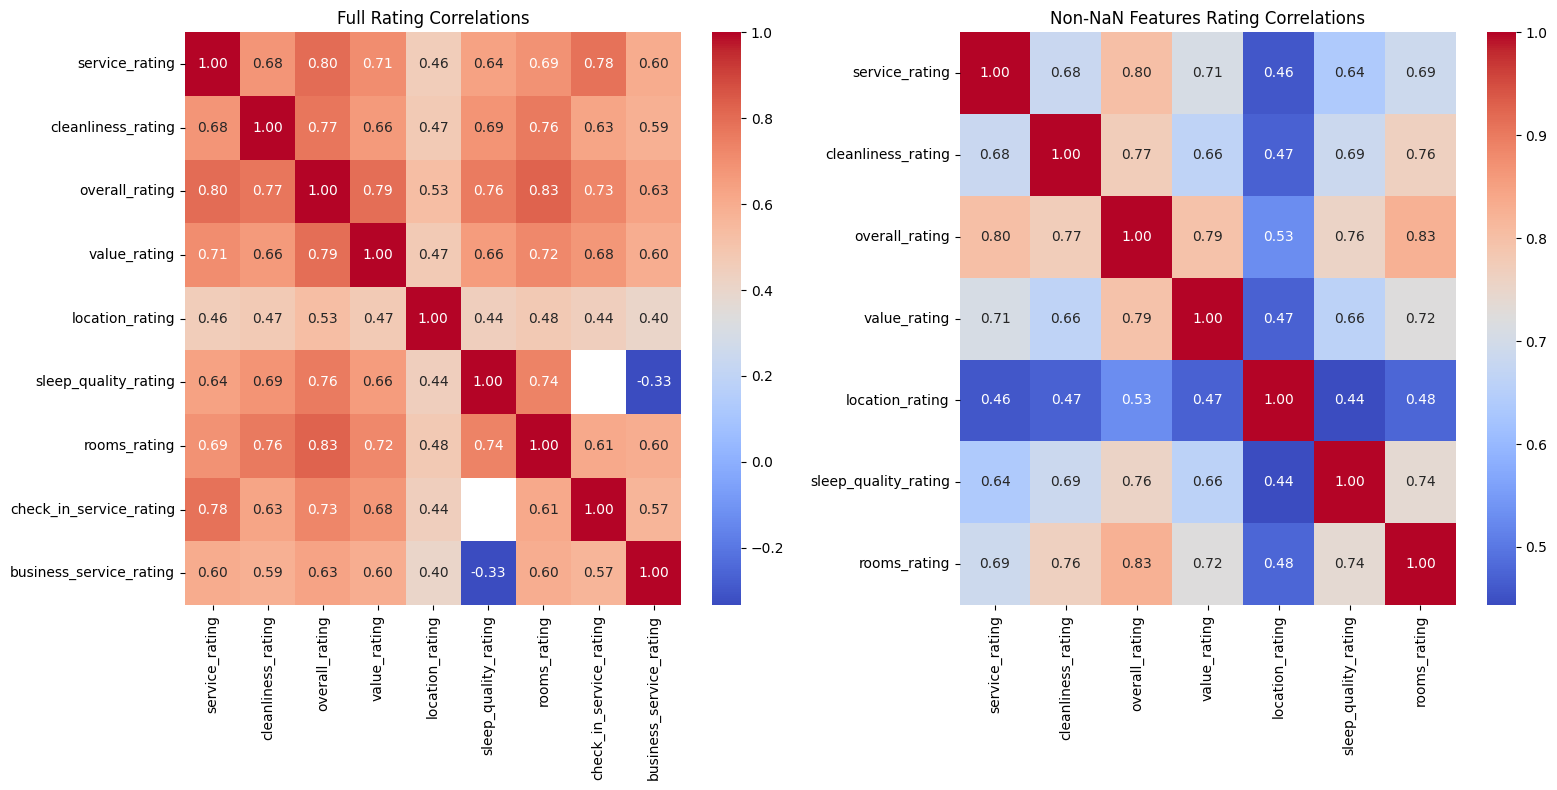

In [20]:
# Get all Rating features
all_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']
corr = reviews_df[all_column].corr()

# Get all NONNULL Rating features
nonnull_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating']
corr_non_NaN = reviews_df[nonnull_column].corr()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot correlation heatmap with seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
sns.heatmap(corr_non_NaN, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])

# Set title for each subplot
axes[0].set_title("Full Rating Correlations")
axes[1].set_title("Non-NaN Features Rating Correlations")

plt.tight_layout()
plt.show()

Key Observations:
* The correlation between some features like overall_rating and rooms_rating are pretty high. The rest of the feature has correlation roughly in 0.44-0.7 range. This shows that the customer gives a quite consistent ratings for many of these columns showing how the highly correlated to one another.
* Sleep quality rating has negative correlation towards business service rating, but considering the low data size, this signal may not be so helpful.


### 2.2. Authors Table

In [21]:
authors_df = dataset['authors']
authors_df.head()

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",
2,3F75FA2DE3464A75D56B30470C0EA060,tymetraveler222,217.0,NaN,701.0,100.0,"Bay City, Michigan",
3,FF09B0D2C8126CC12D54B28424BE585D,BrunoldL,167.0,216.0,607.0,118.0,"Klosterneuburg, Austria",
4,03C0F1D9123788CA0A625769BDE3F313,bwco,131.0,NaN,559.0,48.0,"Morris County, NJ",


In [22]:
# Print number of entries
print(f'Number of entries in the authors dataframe: {len(authors_df):,} entries')

Number of entries in the authors dataframe: 75,349 entries


#### 2.2.1 Analyze Columns

In [23]:
authors_df.columns

Index(['id', 'username', 'num_cities', 'num_helpful_votes', 'num_reviews',
       'num_type_reviews', 'location', 'alias'],
      dtype='object')

##### **Numerical**

In [24]:
authors_df.describe()

,num_cities,num_helpful_votes,num_reviews,num_type_reviews
count,54659.000000,58204.000000,75349.000000,44724.000000
mean,11.844893,16.281974,15.659438,12.764265
std,13.250976,32.315139,25.716283,14.381042
min,2.000000,1.000000,1.000000,3.000000
25%,4.000000,2.000000,2.000000,5.000000
50%,8.000000,7.000000,7.000000,8.000000
75%,15.000000,18.000000,20.000000,15.000000
max,284.000000,964.000000,935.000000,275.000000


In [25]:
authors_df['location'].value_counts()

location
                                      4336
New York City, New York                943
London, United Kingdom                 771
Chicago, Illinois                      655
London                                 631
                                      ... 
Maple Valley WA                          1
Tipton, PA                               1
St-Germain-en-Laye, France               1
Oliver BC                                1
Hanford, California, United States       1
Name: count, Length: 19255, dtype: int64

#### 2.2.2. Visualization

##### Distribution of Customer Statistics

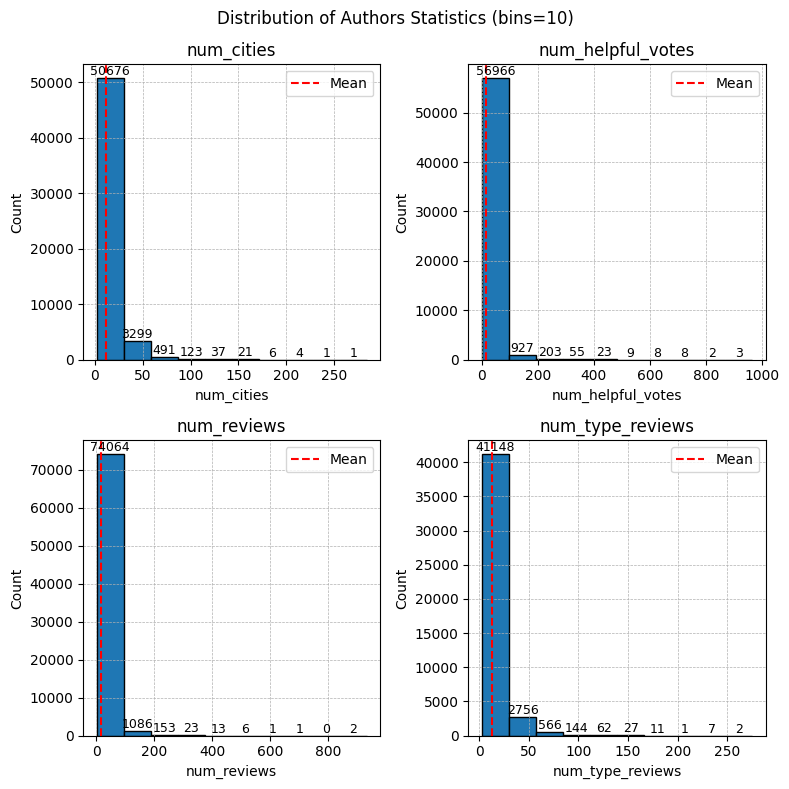

In [26]:
author_column = ['num_cities','num_helpful_votes','num_reviews','num_type_reviews']
bins = 10

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
ax = ax.flatten()

# Loop for every column
for i, col in enumerate(author_column):
    
    # Get the mean for vertical line
    mean = authors_df[col].mean()
    
    # Replace NaN with string "NaN"
    authors_df_filled = authors_df[col].fillna('NaN').astype(str)
    
    # Do value_counts()
    counts = authors_df_filled.value_counts()
    
    # Plot the histogram with bins
    counts, bin_edges, bars = ax[i].hist(authors_df[col], bins=bins, edgecolor='black')

    # Add count labels on top of each bars
    for count, bar in zip(counts, bars):
        ax[i].text(bar.get_x() + bar.get_width()/2, count, int(count), ha='center', va='bottom', fontsize=9)

    # draw the mean line
    ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
    ax[i].grid(linestyle='--', linewidth=0.5)   # Semi transparent grid
    
    ax[i].legend()
    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')

plt.suptitle(f'Distribution of Authors Statistics (bins={bins})')
plt.tight_layout()
plt.show()

Key Observations:
* All the graphs looks right-skewed, meaning that **the number lies on the lower bin with some entries existing on a higher bin**. Even with large number of bins, the same observation stands. This indicates a low contribution by the author on the 4 aspects of the reviews.
* It's notable that **num_cities and num_type_reviews have a slightly higher mean, but this doesn't change the observation** as well.

##### **Correlation matrix of the features**

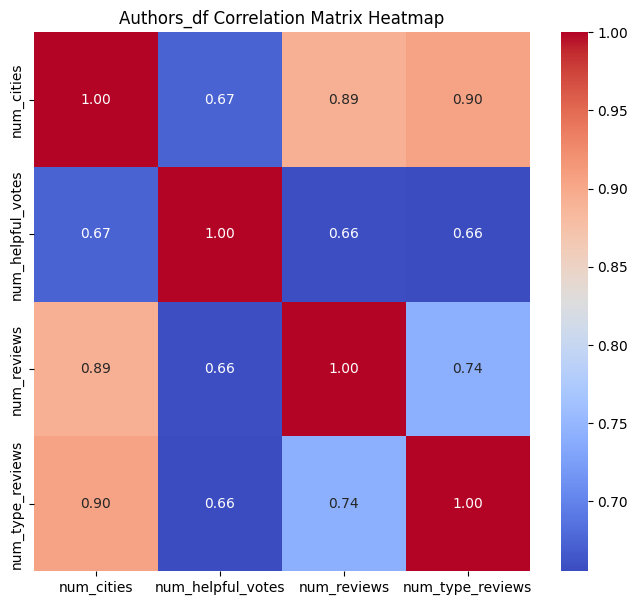

In [27]:
all_column = ['num_cities', 'num_helpful_votes', 'num_reviews', 'num_type_reviews']
corr = authors_df[all_column].corr()

plt.figure(figsize=(8, 7))

# Plot correlation heatmap with seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Authors_df Correlation Matrix Heatmap')
plt.show()

Key Observations:
* Every feature brings minimum information to the database as the correlation is quite high (0.74-0.9).

### 2.3. Hotels table

In [28]:
hotels_df = dataset['hotels']
hotels_df.head()

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
0,214197,1825,2.363836,2.306301,2.261370,2.617534,4.433425,2.595794,2.065205,2.421053,2.265306,1.468153,1.620845,1.453904,2.086366,0.883815,1.695452,1.193036,1.562327,0.666667
1,122005,1774,3.911499,4.221533,3.949267,3.858512,4.665163,4.098581,3.717587,3.623377,3.843137,1.153833,0.710408,0.929920,1.129118,0.362517,0.869507,1.055106,0.693878,0.960000
2,93520,1739,3.522714,3.600920,3.550316,3.557217,4.687752,3.813973,3.456009,2.994012,2.568182,1.587216,1.522748,1.454920,1.514815,0.306288,1.320919,1.417281,2.148760,1.867769
3,93562,1685,4.252819,4.217804,4.077151,4.016617,4.670623,3.936960,3.997033,4.369369,3.757576,0.953324,0.886312,0.999140,1.165390,0.340073,1.365682,1.148491,0.612188,0.997732
4,93618,1647,3.993321,4.101396,3.828780,3.408622,4.602914,4.099425,3.680631,4.134328,3.474359,1.611862,1.177829,1.397046,1.634697,0.568310,1.178711,1.408764,1.472222,0.617284


In [29]:
print(f'Number of entries in the hotels dataframe: {len(hotels_df):,} entries')

Number of entries in the hotels dataframe: 3,380 entries


> The number of hotel in the dataframe is way lower than the number of reviews, but this finding is expected. Actually, the higher the number of reviews compared to the hotel, the better it might be, because then we can dive deeper and obtain more insights for some hotels specifically.

#### 2.3.1 Analyze Columns

In [30]:
hotels_df.columns

Index(['hotel_id', 'num_reviews', 'avg_service_rating',
       'avg_cleanliness_rating', 'avg_overall_rating', 'avg_value_rating',
       'avg_location_rating', 'avg_sleep_quality_rating', 'avg_rooms_rating',
       'avg_check_in_service_rating', 'avg_business_service_rating',
       'service_rating_variance', 'cleanliness_rating_variance',
       'overall_rating_variance', 'value_rating_variance',
       'location_rating_variance', 'sleep_quality_rating_variance',
       'rooms_rating_variance', 'check_in_service_rating_variance',
       'business_service_rating_variance'],
      dtype='object')

In [31]:
hotels_df.describe()

,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
count,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3347.000000,3380.000000,2503.000000,2384.000000,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3229.000000,3380.000000,1617.000000,1441.000000
mean,148.263609,3.848832,3.903125,3.654028,3.750639,4.056105,3.787525,3.670522,3.825460,3.560001,0.995323,0.816929,0.911627,1.021010,0.646740,0.888624,0.866586,0.561381,0.484067
std,218.972431,0.731526,0.806769,0.785323,0.664928,0.649463,0.738412,0.788405,0.872021,0.940848,0.799517,0.733705,0.724587,0.785031,0.612949,0.763353,0.686897,0.778680,0.729571
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,3.571200,3.600000,3.332237,3.500000,3.752552,3.500000,3.299899,3.451613,3.000000,0.250000,0.240000,0.250000,0.374408,0.222222,0.244898,0.250000,0.000000,0.000000
50%,60.500000,4.030892,4.138090,3.833333,3.884615,4.191622,3.987342,3.844960,4.000000,3.687500,0.917128,0.666667,0.846242,0.982063,0.501727,0.767486,0.792883,0.222222,0.000000
75%,184.000000,4.343800,4.468659,4.200505,4.187889,4.533333,4.293641,4.227553,4.444444,4.200000,1.500000,1.208275,1.313167,1.491617,0.906843,1.345405,1.250000,0.979592,0.816327
max,1825.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


#### 2.3.2 Visualization

##### **Distribution of Number of Reviews**

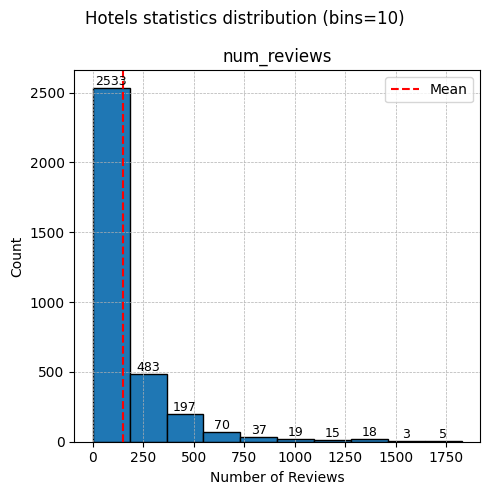

In [32]:
hotel_column = ['num_reviews']
bins = 10

plt.figure(figsize=(5,5))

# Get the mean for vertical line
mean = hotels_df['num_reviews'].mean()

# Replace NaN with string "NaN"
hotels_df_filled = hotels_df['num_reviews'].fillna('NaN').astype(str)

# Do value_counts()
counts = hotels_df_filled.value_counts()

# Plot the histogram with bins
counts, bin_edges, bars = plt.hist(hotels_df['num_reviews'], bins=bins, edgecolor='black')

# Add count labels on top of bars
for count, bar in zip(counts, bars):
    plt.text(bar.get_x() + bar.get_width()/2, count, int(count), ha='center', va='bottom', fontsize=9)

# draw the mean line
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.grid(linestyle='--', linewidth=0.5)

plt.legend()
plt.title('num_reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Count')

plt.suptitle(f'Hotels statistics distribution (bins={bins})')
plt.tight_layout()
plt.show()

Key observations:
* The number of hotel receiving large number of reviews is not bad, but the bar is still right-skewed meaning that it would be way more optimal if all hotels receives equal amoung ot reviews to have a balanced data, although this is hard to achieve in real-life scenario.

##### **Distribution of Reviews per Star Rating**

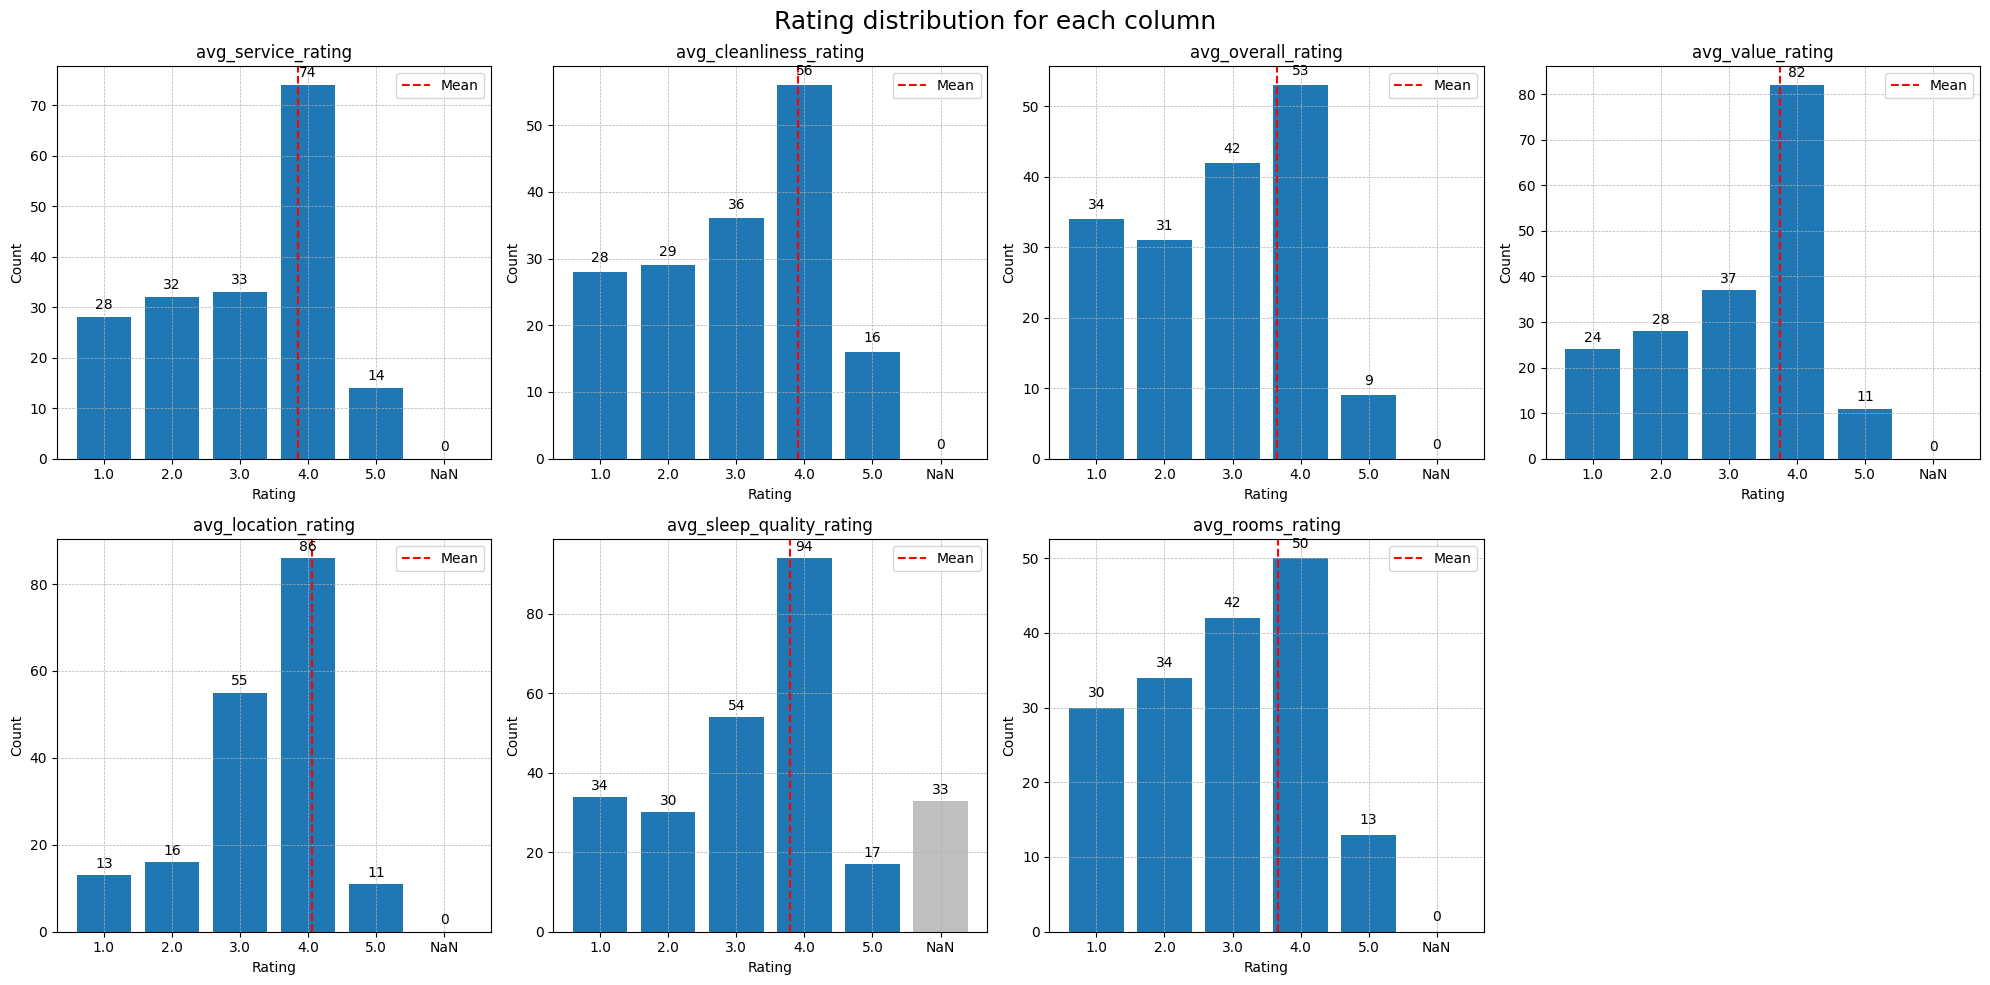

In [33]:

hotel_column = ['avg_service_rating','avg_cleanliness_rating','avg_overall_rating','avg_value_rating','avg_location_rating','avg_sleep_quality_rating','avg_rooms_rating',]

# Prepare subplot
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20,10))
ax = ax.flatten()

# Loop for each column
for i, col in enumerate(hotel_column):
    
    # Get the mean for vertical line
    mean = hotels_df[col].mean()
    
    # Replace NaN with string "NaN"
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    
    # Do value_counts()
    counts = hotels_df_filled.value_counts()
    
    # Reindex so that we can show the NaN values as well
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    # Plot the bar in the subplot
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to semi-transparent
    bars[-1].set_alpha(0.5)
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

# Hide the last subplot
ax[-1].axis('off')

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

Key Observations:
* Most hotels don't struggle with their location rating as the mean and count for high star rating looks good.
* On the rest of the columns, although rating of the hotels averages at 4 but the cummulative of the ratin 103 is actually significant, showing how major amount of hotels still receives bad scores over this rating aspect.

##### **Correlation matrix of the features**

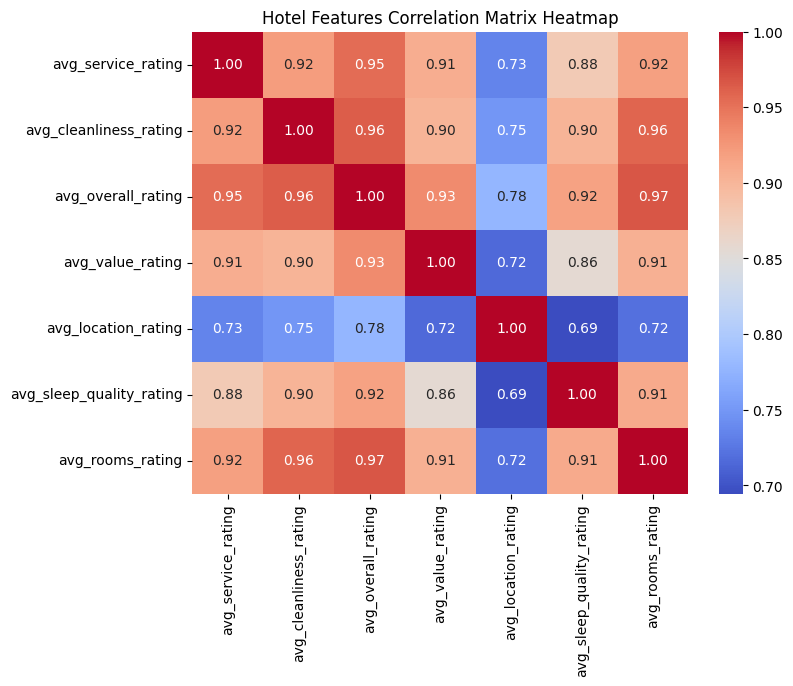

In [34]:

all_column = ['avg_service_rating','avg_cleanliness_rating','avg_overall_rating','avg_value_rating','avg_location_rating','avg_sleep_quality_rating','avg_rooms_rating']
corr = hotels_df[all_column].corr()

plt.figure(figsize=(8, 6))

# Plot corelation heatmap with seaborn
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Hotel Features Correlation Matrix Heatmap')
plt.show()

Key Observations:
* There is not much observation for this part as these columsn are just an aggregation of all the reviews, but now the number might be more realiable as the weight for each hotel are now equal. Even so, the findings will be very identical as the previous correlation heatmap.


---

## 3. Feature Engineering

### 3.1. **review_frequency** (authors_df)

Whether an author frequently write reviews compared to the median of all authors.

In [35]:
authors_df.head(2)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",


We need to check the skewness of the data before doing the threshold, therefore let's visualize the feature

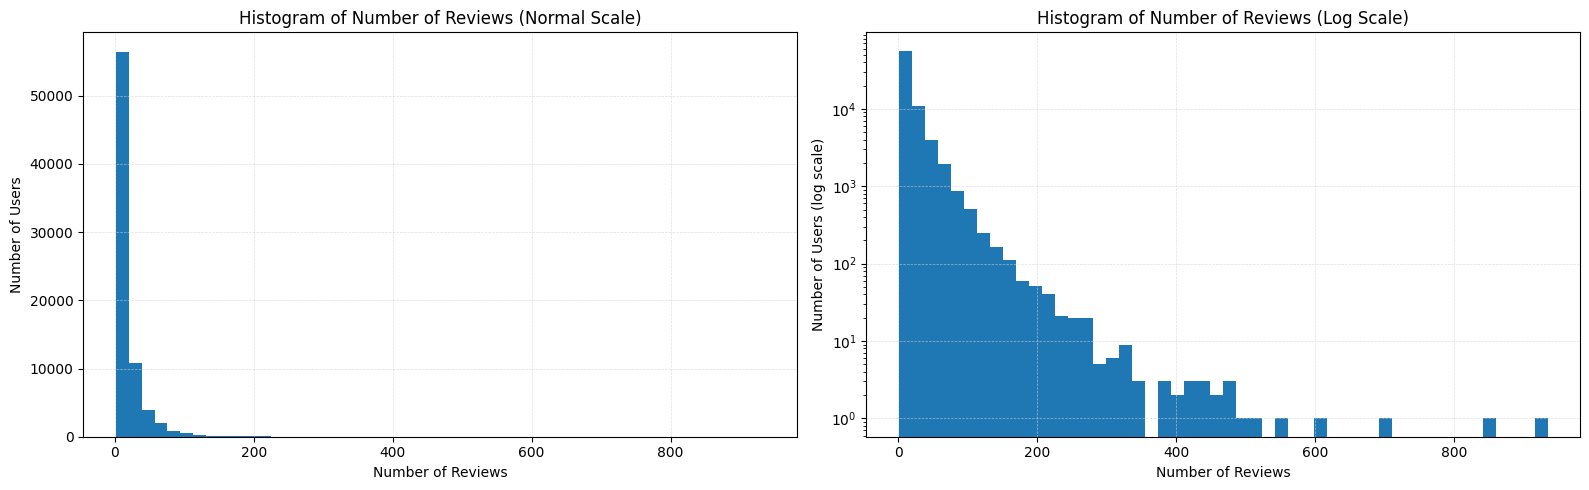

In [36]:
# Get the value counts of num_reviews
authors_df['num_reviews'].value_counts()

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Normal scale histogram
axes[0].hist(authors_df['num_reviews'], bins=50)
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Histogram of Number of Reviews (Normal Scale)')
axes[0].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

# Log scale histogram
axes[1].hist(authors_df['num_reviews'], bins=50, log=True)
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].set_title('Histogram of Number of Reviews (Log Scale)')
axes[1].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


The heavy skewness makes it hard to use simple thresholding with mean, std, or median. Our approach will use the quantile based categorization so that we have a balanced category.

In [37]:
# Set the quantile
q1 = authors_df['num_reviews'].quantile(0.33)
q2 = authors_df['num_reviews'].quantile(0.66)

print('=' * 40)
print('category')
print('=' * 40)
print(f'range from 0 - {q1} ===> Low')
print(f'range from {q1} - {q2} ===> Medium')
print(f'range from {q2} - infinity ===> High')
print('=' * 40)

def categorize_reviews(n):
    if n <= q1:
        return 'low'
    elif n <= q2:
        return 'medium'
    else:
        return 'high'

authors_df['review_frequency'] = authors_df['num_reviews'].apply(categorize_reviews)

category
range from 0 - 3.0 ===> Low
range from 3.0 - 13.0 ===> Medium
range from 13.0 - infinity ===> High


Now we print the total for each frequency.

In [38]:
for freq in ['low', 'medium', 'high']:
    print(f"{freq.upper()} frequency total: {len(authors_df[authors_df['review_frequency'] == freq]):,}")

LOW frequency total: 28,732
MEDIUM frequency total: 21,495
HIGH frequency total: 25,122


In [39]:
# IF USING MEAN STD OR MEDIAN
freq_df = authors_df.copy()

mean = freq_df['num_reviews'].mean()
median = freq_df['num_reviews'].median()
std = freq_df['num_reviews'].std()

freq_df['freq_mean'] = freq_df['num_reviews'] > mean
freq_df['freq_mean_std'] = freq_df['num_reviews'] > (mean + std)
freq_df['freq_median'] = freq_df['num_reviews'] > median

for freq in ['freq_mean', 'freq_mean_std', 'freq_median']:
    print(f'\n{freq}')
    print(f'frequent: {freq_df[freq].sum():,}')
    print(f'not frequent: {len(freq_df) - (freq_df[freq].sum()):,}')


freq_mean
frequent: 22,493
not frequent: 52,856

freq_mean_std
frequent: 7,252
not frequent: 68,097

freq_median
frequent: 35,274
not frequent: 40,075


Using the mean and std will make the class very unstable.

Using median might be a good choice, but it will only allow binary categorization instead of multi level category.

In [40]:
# Print 10 random samples
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency
8809,382E1A68AAD2D0B8348D61ABE8368652,madagou,23.0,11.0,36.0,27.0,Montreuil,,high
48561,4BB46BDAFF4487E7D323E2DC91851120,AmandaJ842,2.0,2.0,3.0,3.0,"Plainfield, Illinois",,low
54861,8904893AA0C2353AE386220F2F1E5085,Mamacita1218,2.0,NaN,2.0,NaN,Ohio,,low
60138,12EABEB67240F0EECE6F47975EEB2C67,Laura H,NaN,1.0,1.0,NaN,New York,,low
5745,5BCA545EE74E99227CDEEDCE39F8CDC4,JULOfrVan,28.0,112.0,50.0,25.0,Van BC,,high
45556,74A4FDD68CDAEC2146C0B09176EF460C,jazzabeller,3.0,11.0,4.0,4.0,"Singapore, Singapore",,medium
71091,CEED171CF77659905DE40532ED3A518D,MIKE R,NaN,NaN,1.0,NaN,FLAGLER BEACH,,low
51549,370F3443BB4BF53B08F4B654213DFEF4,Lulu23Manhattan,2.0,NaN,2.0,NaN,Manhattan,,low
941,868C1A7F3DFA04E5127B7CE2AD750E5E,Tellurian,60.0,240.0,106.0,90.0,"Bar Harbor, Maine",,high
33538,34E1EC1B26B3FF9BBB87C67C35FDD023,ndnzfan,7.0,10.0,8.0,7.0,West Virginia,,medium


For the visualization

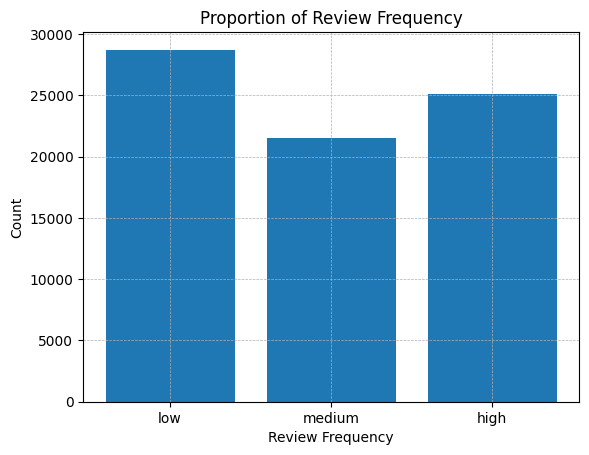

In [41]:
freq_counts = authors_df['review_frequency'].value_counts()

order = ['low', 'medium', 'high']
freq_counts = freq_counts.reindex(order, fill_value=0)

# Plot
plt.grid(linestyle='--', linewidth=0.5)
plt.bar(freq_counts.index, freq_counts.values)
plt.xlabel("Review Frequency")
plt.ylabel("Count")
plt.title("Proportion of Review Frequency")
plt.show()

### 3.2. **helpful_votes_ratio** (authors_df)

Ratio of how many helpful reviews produced by the user compared to the number of reviews published

* formula: number of helpful votes / number of reviews

In [42]:
# Fill NaN to prevent error
authors_df[['num_helpful_votes', 'num_reviews']] = authors_df[['num_helpful_votes', 'num_reviews']].fillna(0)

# Check validity if helpful notes is larger than num_reviews (invalid)
authors_df['num_helpful_votes'] = authors_df[['num_helpful_votes', 'num_reviews']].min(axis=1)

authors_df['helpful_votes_ratio'] = np.where(
    (authors_df['num_helpful_votes'] == 0) | (authors_df['num_reviews'] == 0), 0, authors_df['num_helpful_votes'] / authors_df['num_reviews']
)

authors_df.head(2)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency,helpful_votes_ratio
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",,high,0.944385
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",,high,0.453801


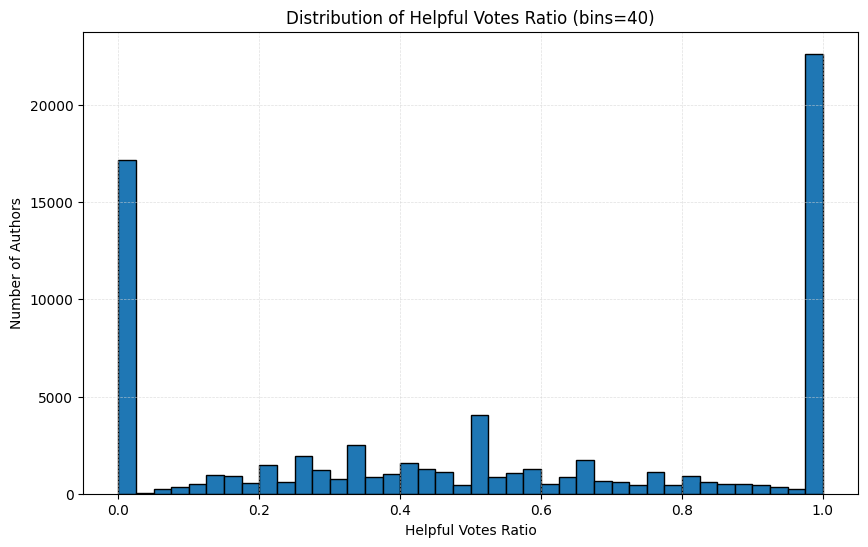

In [43]:
bins = 40

plt.figure(figsize=(10,6))

plt.hist(authors_df['helpful_votes_ratio'], bins=bins, edgecolor='black')

plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title(f'Distribution of Helpful Votes Ratio (bins={bins})')
plt.xlabel('Helpful Votes Ratio')
plt.ylabel('Number of Authors')

plt.show()

### 3.3. **avg_stars_given** authors_df

Average of stars given by a user in all their reviews

* formula: mean of all stars given in reviews dataframe.

In [44]:
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


In [45]:
stars_df = reviews_df[['review_id', 'author_id', 'service_rating', 'cleanliness_rating', 'overall_rating', 	'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']].copy()
stars_df['author_id'].isna().sum()

stars_df


,review_id,author_id,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
0,145753174,714F49AC057498AEA304343E569A2A03,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
1,81870377,74C5A4455E1AAE46B0C54FC6CCBD7033,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN
2,33732815,CC2C523A197E7024A07BE083E1573E75,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN
3,32773886,D879DE1351CB445AEF3B247EF25CFC00,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN
4,38157829,404B9AF8897A742142CEBF4F0596EF5E,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
79995,50826156,309A277A5D221634DA28090144520A10,4.0,2.0,3.0,2.0,4.0,NaN,3.0,NaN,NaN
79996,123858080,8C7A26020CD00F6C88B7A2537AB0F3BE,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
79997,118987846,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,5.0,5.0,4.0,3.0,5.0,3.0,4.0,NaN,NaN
79998,109895397,220F304A84F86A2E5AF856F270C775D5,5.0,5.0,5.0,4.0,5.0,5.0,4.0,NaN,NaN


In [46]:
rating_cols = [
    'service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating',
    'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating',
    'business_service_rating'
]

stars_df = stars_df.groupby('author_id')[rating_cols].mean()
stars_df['final_overall_avg'] = stars_df.mean(axis=1)

# Reset index and rename to align with authors_df
stars_df.reset_index(inplace=True)
stars_df.rename(columns={'author_id': 'id'}, inplace=True)
stars_df.sample(5)

,id,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,final_overall_avg
35385,77CB6E2BC3480C9F9A21E8C2D4ACF7F8,4.0,4.0,4.0,5.0,4.0,NaN,4.0,NaN,NaN,4.166667
48735,A59E7C65EAB9120832FE3ADE2F6BB270,1.0,2.0,1.0,1.0,2.0,4.0,3.0,NaN,NaN,2.000000
14481,30FA46730F0DA86DDB5F6FF6DEE62FE8,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000
42272,8F5E7F6506FFA5EE62CE6B18253173AC,5.0,5.0,5.0,5.0,5.0,NaN,5.0,5.0,5.0,5.000000
62409,D3CB26442520A48CE8D3B89E267E46B6,4.0,5.0,4.0,5.0,4.0,NaN,4.0,NaN,NaN,4.333333


Merge the stars_df back to authors_df

In [47]:
authors_df = authors_df.merge(stars_df, on='id', how='left')
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency,helpful_votes_ratio,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,final_overall_avg
50335,81ED46172C5C9DEE20F73F46CDF60869,Aardvaark52,2.0,0.0,3.0,NaN,"Crewe, United Kingdom",,low,0.000000,2.0,4.0,4.0,3.0,5.0,NaN,4.0,NaN,NaN,3.666667
9051,29D8FBA0C7DA3F6CC73E2185BDD5081E,TJM1973,12.0,12.0,35.0,9.0,"San Luis Obispo, California",,high,0.342857,4.0,5.0,4.0,5.0,3.0,5.0,5.0,NaN,NaN,4.428571
72075,C8ABCE91DF7BB091068D3C35B2806A02,Janet J,NaN,0.0,1.0,NaN,"Venice, California",,low,0.000000,5.0,4.0,4.0,5.0,5.0,5.0,5.0,NaN,NaN,4.714286
35749,91F26F1B1DFAFBFE4D4EF3EF98FBCE3D,Christine427,7.0,4.0,7.0,7.0,"Bury st Edmunds, England",,medium,0.571429,5.0,5.0,5.0,5.0,4.0,NaN,4.0,NaN,NaN,4.666667
51548,371452DE528A81D61D66F7A7EE52CAAC,jhrabak5,2.0,2.0,2.0,NaN,"Canal Fulton, Ohio, USA",,low,1.000000,4.0,4.0,5.0,4.0,5.0,4.0,5.0,NaN,NaN,4.428571
32863,4F432AC6B1AA1BAE5E997C17A95BE69A,spymaster0012,7.0,9.0,9.0,7.0,"Phoenix, Az.",,medium,1.000000,4.0,2.0,4.0,3.0,5.0,NaN,3.0,4.0,3.0,3.500000
46838,F26EF045226105DBB01C781413FAA206,blaze_amaze,3.0,2.0,3.0,3.0,Toronto,,low,0.666667,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000
5637,C792063F0ADE04CD9DCE6D82C43850C4,SandBAtlanta,19.0,12.0,50.0,9.0,Atlanta,,high,0.240000,4.0,4.0,4.0,3.0,5.0,4.0,4.0,NaN,NaN,4.000000
23444,111B1EC3D4FE5FF6C28405A404EC0B5B,bookthyme,6.0,7.0,15.0,5.0,,,high,0.466667,5.0,5.0,5.0,5.0,5.0,NaN,5.0,NaN,NaN,5.000000
8742,7062F4581A4D175C7093009CCF9C9499,4FantasticGolfers,15.0,36.0,36.0,10.0,"Albuquerque, NM",,high,1.000000,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000


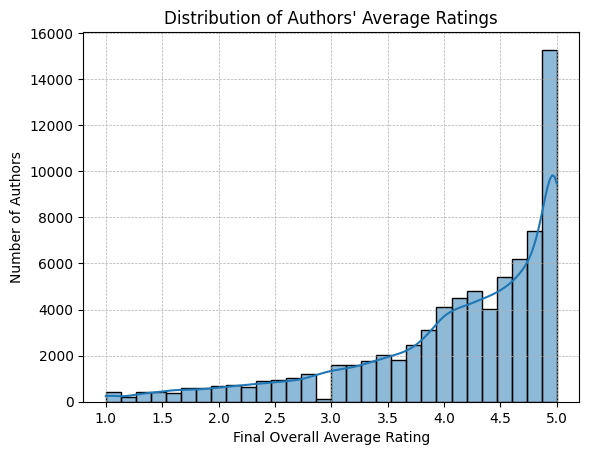

In [48]:
sns.histplot(authors_df['final_overall_avg'], bins=30, kde=True)
plt.xlabel("Final Overall Average Rating")
plt.ylabel("Number of Authors")
plt.title("Distribution of Authors' Average Ratings")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

You can see the tendencies of user giving 5 stars by default is very high. This proves that the authors will most likely give 5 stars ratings. Although this shows that the data is not skewed towards negative reviews, but having too much 5 stars ratings average can also add up complexity due to certain bias of the authors.

### 3.4. **ratings_variance** (hotels_df)

Indicate whether a hotel consistently receives certain number of starts or not.

* formula: average of squared differences between each data point and the mean

In [49]:
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


In [ ]:
rating_columns = [
    'service_rating', 'cleanliness_rating', 'overall_rating',
    'value_rating', 'location_rating', 'sleep_quality_rating',
    'rooms_rating', 'check_in_service_rating', 'business_service_rating'
]

# Variance columns were pre-computed in _subset_variance() (01_data_preparation.ipynb)
# and stored in the hotels table at load time, no per-run aggregation needed.

In [51]:
hotels_df.sample(10)

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
979,98944,154,3.876623,4.012987,3.701299,3.636364,4.500000,3.898990,3.681818,3.733333,3.700000,1.581597,1.138889,0.909722,1.164931,0.909722,1.022222,1.472222,1.000000,NaN
2951,223152,12,4.416667,4.166667,3.833333,4.166667,4.250000,4.000000,4.166667,NaN,NaN,0.000000,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,NaN,NaN
1737,112253,56,4.428571,4.589286,4.678571,4.071429,4.910714,4.511628,4.517857,4.000000,4.000000,0.628099,0.247934,0.429752,0.446281,0.148760,0.666667,0.429752,NaN,NaN
2444,320049,25,4.560000,4.480000,4.360000,4.400000,4.240000,4.250000,4.240000,NaN,NaN,2.888889,2.000000,2.000000,0.666667,0.888889,0.000000,0.888889,NaN,NaN
1925,1176612,46,3.500000,3.478261,3.282609,3.847826,3.782609,3.419355,3.478261,4.500000,4.500000,0.859375,1.250000,1.250000,0.484375,0.437500,0.560000,0.937500,NaN,NaN
2222,108521,33,4.242424,4.212121,3.939394,4.212121,4.121212,4.040000,3.939394,3.500000,4.500000,0.687500,0.250000,0.687500,1.000000,0.687500,1.555556,1.000000,0.000000,0.00
2918,108831,13,3.153846,2.846154,2.538462,3.230769,4.000000,3.100000,2.769231,NaN,NaN,0.888889,3.555556,2.000000,3.555556,0.222222,0.250000,3.555556,NaN,NaN
432,112303,328,4.216463,4.289634,4.015244,4.042683,4.655488,4.055319,3.859756,4.560000,4.333333,0.987906,0.816447,0.927708,1.128729,0.226283,1.317338,0.846547,0.222222,0.25
1752,267183,55,1.836364,1.745455,1.654545,2.200000,3.145455,1.571429,1.490909,4.000000,4.000000,2.359375,1.734375,1.437500,1.984375,1.187500,0.859375,1.734375,NaN,NaN
745,122015,209,3.583732,4.028708,3.693780,3.851675,4.545455,3.483051,3.334928,3.808511,3.342857,1.247230,0.809557,0.889889,1.518698,0.349030,1.357278,1.232687,0.359375,0.24


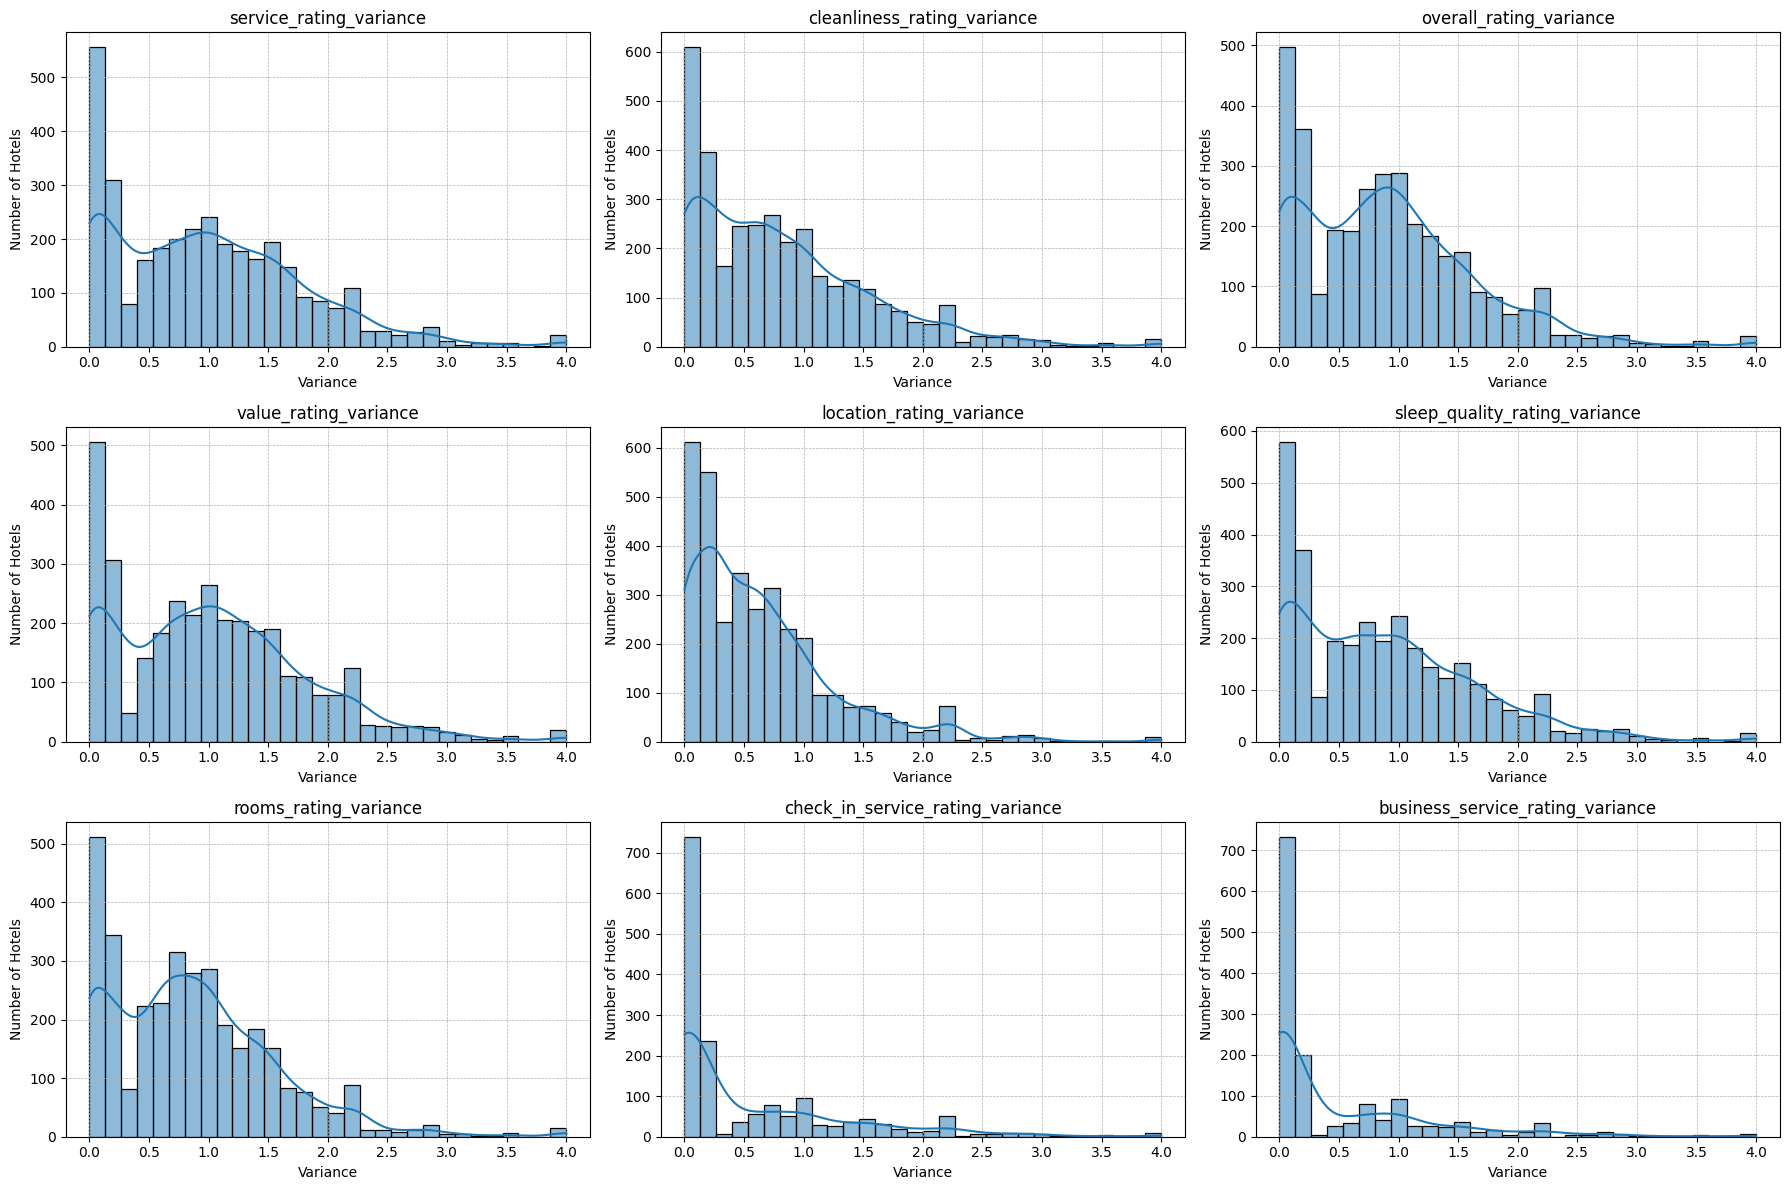

In [52]:
variance_cols = [col for col in hotels_df.columns if 'variance' in col]

num_cols = 3
num_rows = (len(variance_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows*4))
axes = axes.flatten()

for i, col in enumerate(variance_cols):
    sns.histplot(hotels_df[col], bins=30, kde=True, ax=axes[i])
    axes[i].grid(linestyle='--', linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("Variance")
    axes[i].set_ylabel("Number of Hotels")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:
* Based on the graph we can see that the variance lies within 0 and 1, this is still fine althoug we expect the peak to be exactly at 0.
* You can see that the graph has increasing variance on the tail part.
* This finding means that most authors consistently give similar ratings which makes the variance low, so they all produce similar agreement on the ratings. But some users are of course very subjective and can rate differenly even though majority of the other authors rates good, which increases the variance on the tail part.
* The most consistent rating can only be seen on location rating and cleanliness.

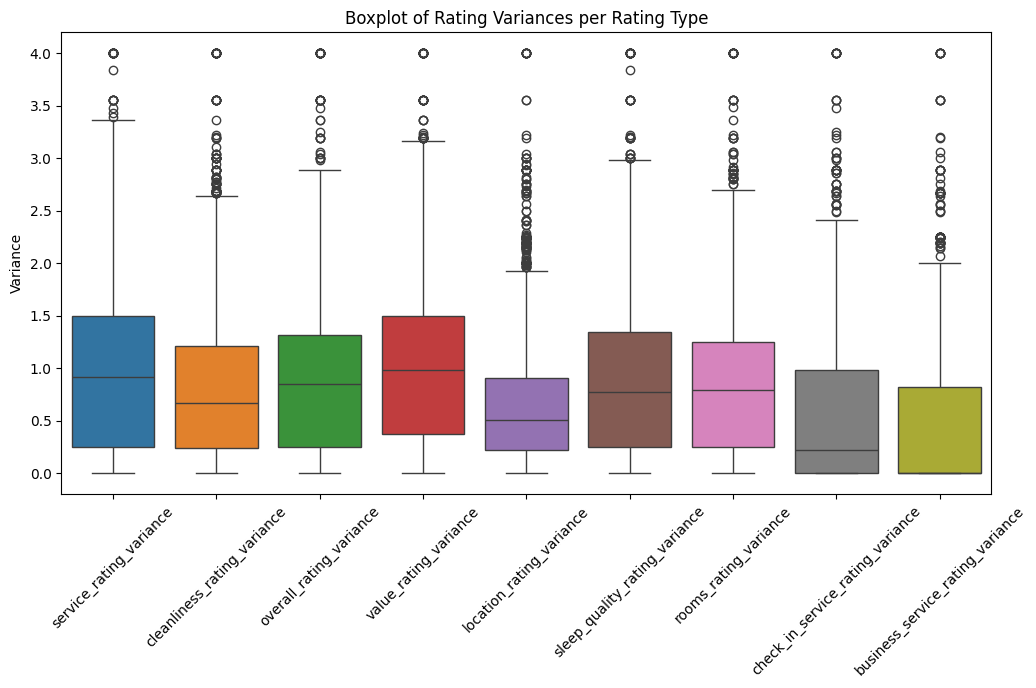

In [53]:
plt.figure(figsize=(12,6))

sns.boxplot(data=hotels_df[variance_cols])

plt.xticks(rotation=45)
plt.ylabel("Variance")
plt.title("Boxplot of Rating Variances per Rating Type")
plt.show()


Observations:
* Similar observations can be seen here, but more detail about the quartile, min, max, and even outliers are now visible.
* Still location rating has the lower variance (without consideting check in and business service rating) that prove its consistency in receiving the rating.

---

## 4. (Extra exploration) Analytics by Business Questions

### **4.1. Best and worst hotels from each service category?**

In [54]:
hotels_df.head()

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
0,214197,1825,2.363836,2.306301,2.261370,2.617534,4.433425,2.595794,2.065205,2.421053,2.265306,1.468153,1.620845,1.453904,2.086366,0.883815,1.695452,1.193036,1.562327,0.666667
1,122005,1774,3.911499,4.221533,3.949267,3.858512,4.665163,4.098581,3.717587,3.623377,3.843137,1.153833,0.710408,0.929920,1.129118,0.362517,0.869507,1.055106,0.693878,0.960000
2,93520,1739,3.522714,3.600920,3.550316,3.557217,4.687752,3.813973,3.456009,2.994012,2.568182,1.587216,1.522748,1.454920,1.514815,0.306288,1.320919,1.417281,2.148760,1.867769
3,93562,1685,4.252819,4.217804,4.077151,4.016617,4.670623,3.936960,3.997033,4.369369,3.757576,0.953324,0.886312,0.999140,1.165390,0.340073,1.365682,1.148491,0.612188,0.997732
4,93618,1647,3.993321,4.101396,3.828780,3.408622,4.602914,4.099425,3.680631,4.134328,3.474359,1.611862,1.177829,1.397046,1.634697,0.568310,1.178711,1.408764,1.472222,0.617284


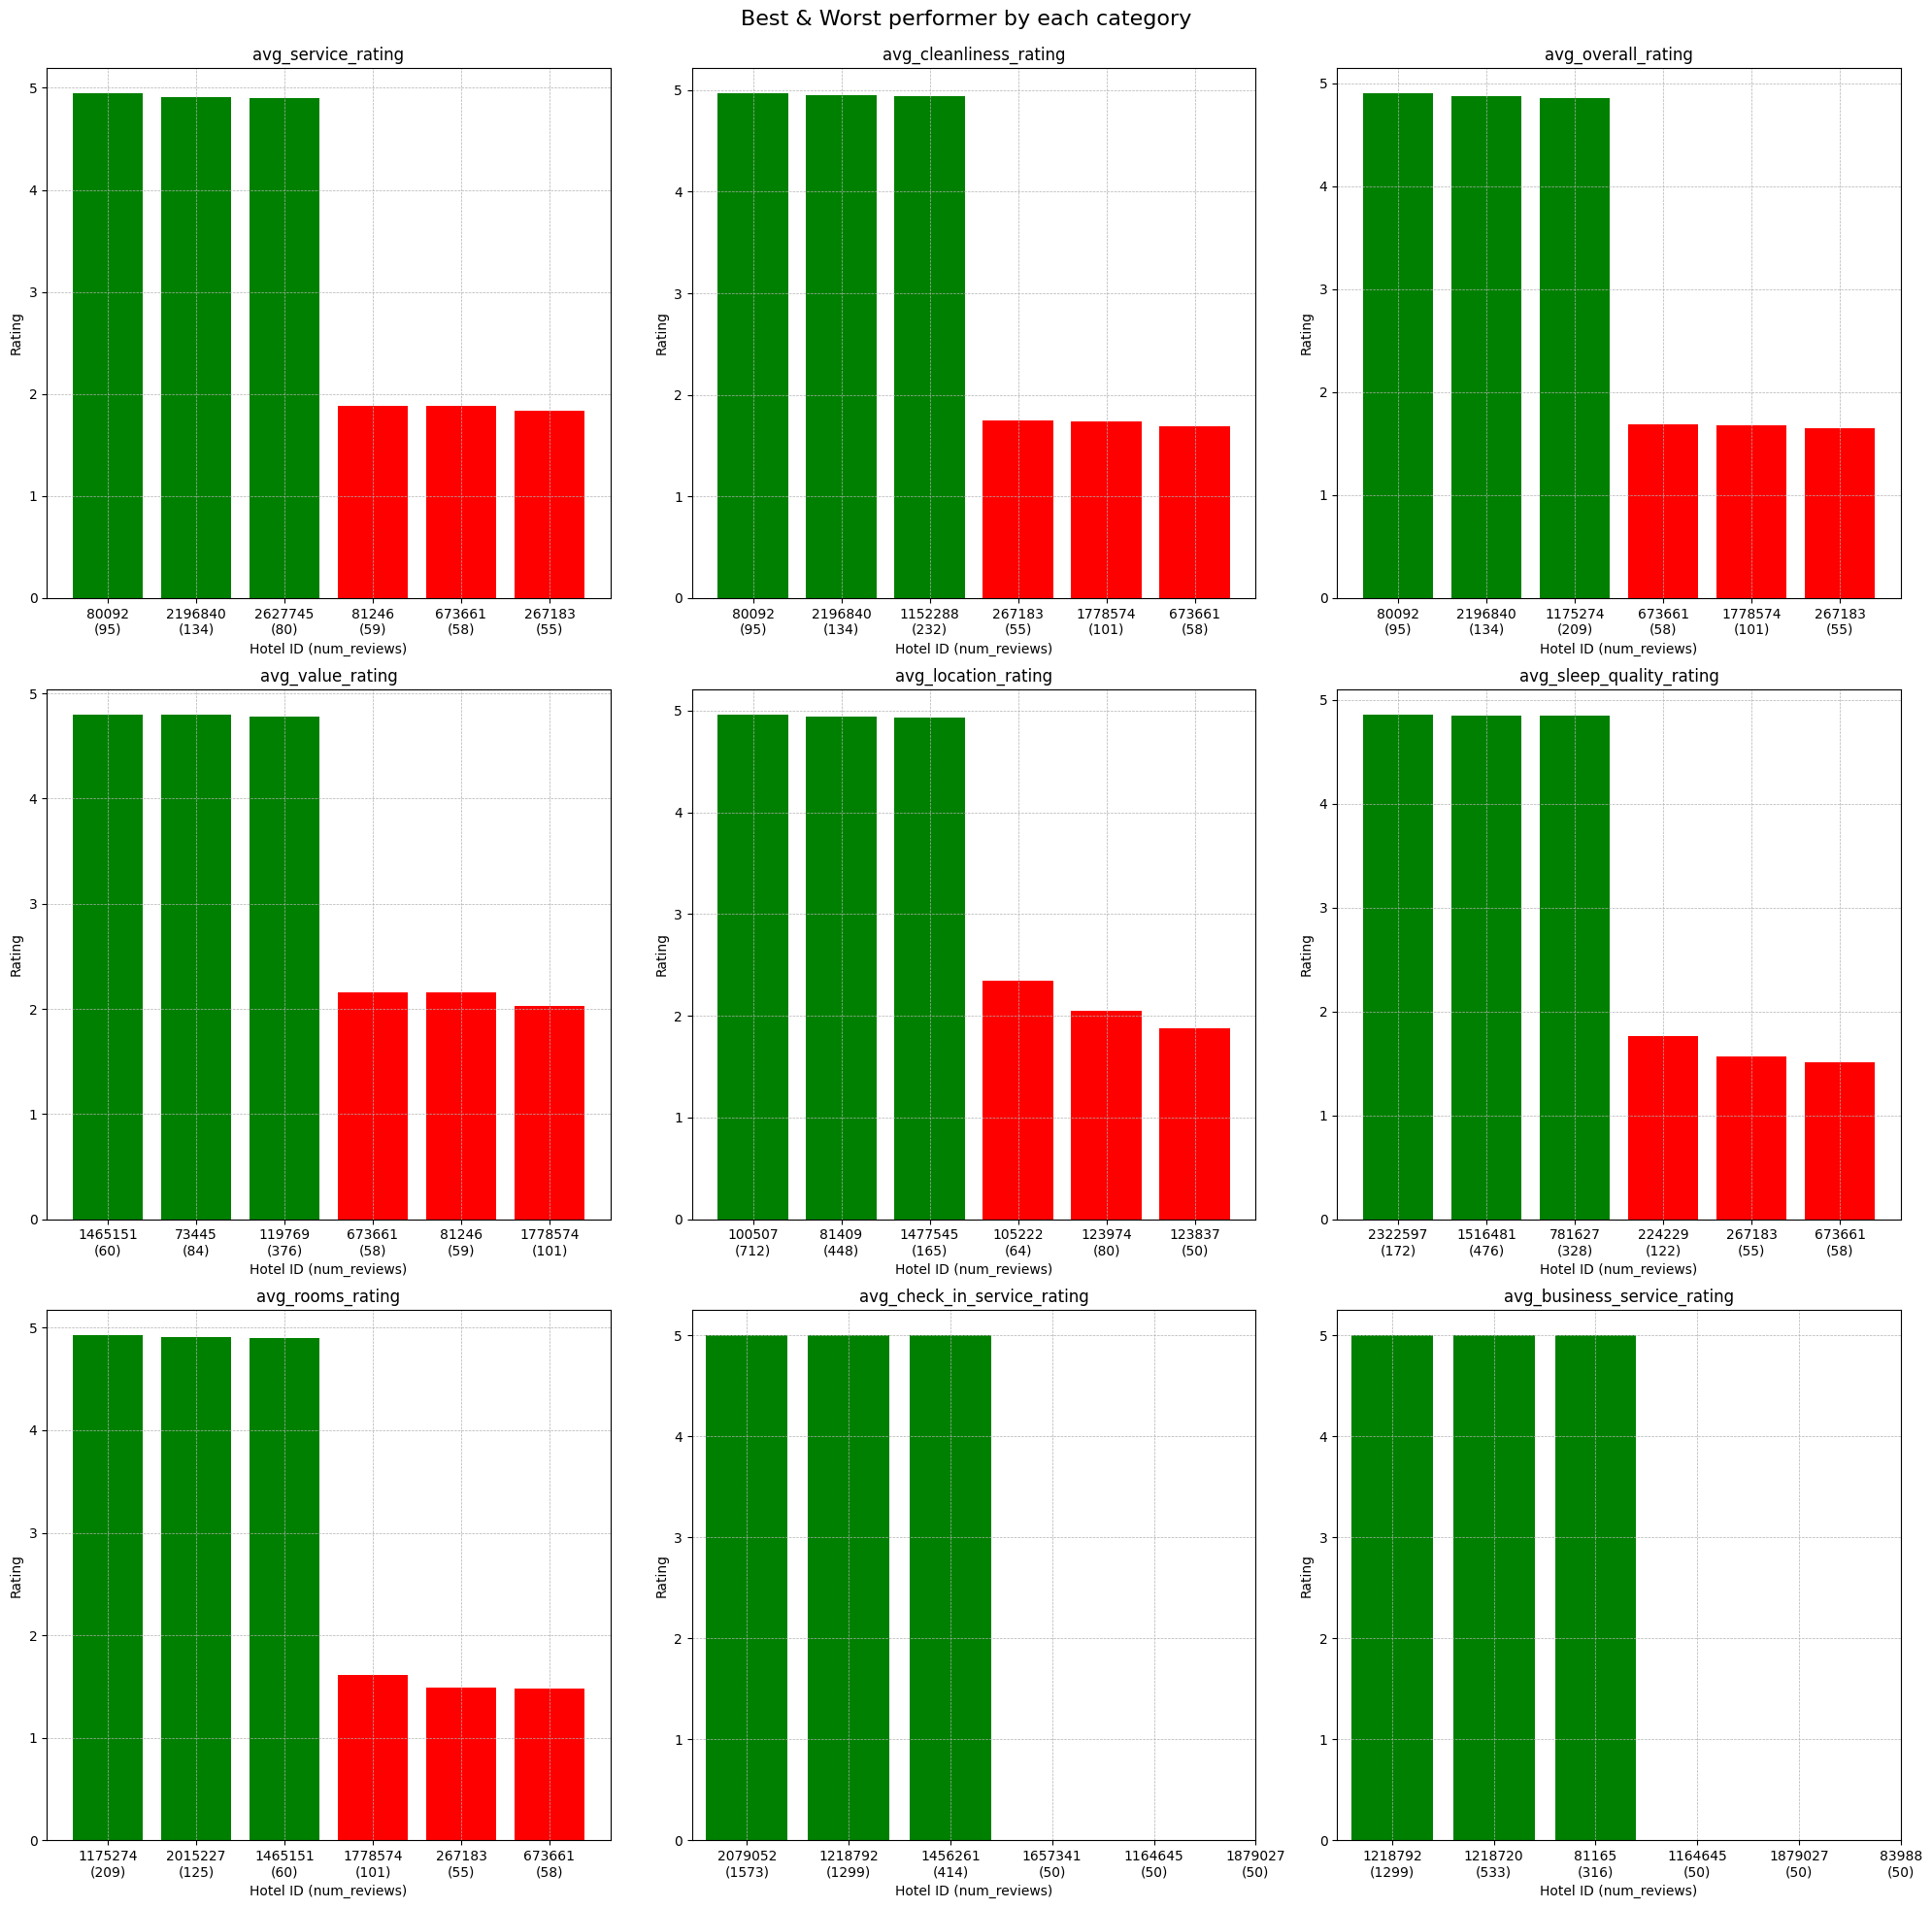

In [55]:
rating_cols = ['avg_service_rating','avg_cleanliness_rating', 'avg_overall_rating', 'avg_value_rating', 'avg_location_rating', 'avg_sleep_quality_rating', 'avg_rooms_rating','avg_check_in_service_rating', 'avg_business_service_rating']
vars_cols = ['service_rating_variance','cleanliness_rating_variance', 'overall_rating_variance', 'value_rating_variance', 'location_rating_variance', 'sleep_quality_rating_variance', 'rooms_rating_variance','check_in_service_rating_variance', 'business_service_rating_variance']

# Minimum threshold of review to be considered for calculation (hotel with only 1 rating with 5 stars would dominate without this filtering process)
min_reviews=50

# number of best and worst hotels to show
top_n = 3

# Remove hotels with num_reviews lower than threshold
df_filtered = hotels_df[hotels_df['num_reviews'] >= min_reviews].copy()

# Prepare subplot
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
ax = ax.flatten()

for i, col in enumerate(rating_cols):
    
    # Getting the variance column of the corresponding avg
    var_col = vars_cols[i]
    
    # Sort hotels by highest rating, highest numbers of reviews, then by lowest variance
    df_sorted = df_filtered.sort_values(
        by=[col, 'num_reviews', var_col],
        ascending=[False, False, True]
    )
    
    # Select best and worst n
    best_n = df_sorted.head(top_n)
    worst_n = df_sorted.tail(top_n)
    
    # Combine for plotting
    combined = pd.concat([best_n, worst_n])
    
    # create x axis labels with hotel_id and the num of reviews
    x_labels = [f"{hid}\n({rev})" for hid, rev in zip(combined['hotel_id'], combined['num_reviews'])]
    x_pos = range(len(combined))
    
    # Color for the bar
    colors = ['green'] * len(best_n) + ['red'] * len(worst_n)
    
    # Plot the bar plot
    ax[i].bar(x_pos, combined[col].values, color=colors)
    
    ax[i].grid(linestyle='--', linewidth=0.5)
    ax[i].set_title(f"{col}")
    ax[i].set_ylabel("Rating")
    ax[i].set_xlabel("Hotel ID (num_reviews)")
    ax[i].set_xticks(x_pos)
    ax[i].set_xticklabels(x_labels)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.suptitle("Best & Worst performer by each category", fontsize=16)
plt.show()

### **4.2. Rating for mobile vs non mobile**

In [56]:
reviews_df

mobile_df = reviews_df[reviews_df['via_mobile'] == 1]
non_mobile_df = reviews_df[reviews_df['via_mobile'] == 0]

In [57]:
mobile_df.describe()

,date_stayed,num_helpful_votes,review_date,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,reviews_days_since_stay
count,5345,5345.000000,5345,5345.0,5345.000000,5345.000000,5345.000000,5345.000000,5345.000000,1.0,5345.000000,0.0,0.0,5345
mean,2012-01-24 06:53:48.886810112,0.580355,2012-02-14 01:24:51.861552896,1.0,3.998129,4.200935,3.936389,3.864733,4.395510,5.0,3.900655,NaN,NaN,20 days 18:31:02.974742750
min,2009-11-01 00:00:00,0.000000,2009-12-23 00:00:00,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,5.0,1.000000,NaN,NaN,0 days 00:00:00
25%,2011-09-01 00:00:00,0.000000,2011-09-30 00:00:00,1.0,3.000000,4.000000,3.000000,3.000000,4.000000,5.0,3.000000,NaN,NaN,11 days 00:00:00
50%,2012-02-01 00:00:00,0.000000,2012-03-03 00:00:00,1.0,5.000000,5.000000,4.000000,4.000000,5.000000,5.0,4.000000,NaN,NaN,20 days 00:00:00
75%,2012-07-01 00:00:00,1.000000,2012-07-29 00:00:00,1.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.000000,NaN,NaN,28 days 00:00:00
max,2012-12-01 00:00:00,17.000000,2012-12-19 00:00:00,1.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.000000,NaN,NaN,60 days 00:00:00
std,NaN,1.068372,NaN,0.0,1.276954,1.113522,1.195705,1.262157,0.925954,NaN,1.199445,NaN,NaN,12 days 01:19:01.157922103


In [58]:
non_mobile_df.describe()

,date_stayed,num_helpful_votes,review_date,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,reviews_days_since_stay
count,74655,74655.000000,74655,74655.0,74655.000000,74655.000000,74655.000000,74655.000000,74655.000000,58189.000000,74655.000000,6337.00000,4315.000000,74655
mean,2011-04-05 17:05:32.585894912,0.644324,2011-04-29 17:24:19.819168,0.0,4.131592,4.253071,4.002853,3.935329,4.429911,4.100964,3.965454,4.01941,3.674160,24 days 00:18:47.233273056
min,2007-12-01 00:00:00,0.000000,2008-01-01 00:00:00,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,0 days 00:00:00
25%,2010-05-01 00:00:00,0.000000,2010-05-22 00:00:00,0.0,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.00000,3.000000,14 days 00:00:00
50%,2011-10-01 00:00:00,0.000000,2011-10-28 00:00:00,0.0,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.00000,4.000000,23 days 00:00:00
75%,2012-06-01 00:00:00,1.000000,2012-06-25 00:00:00,0.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,32 days 00:00:00
max,2012-12-01 00:00:00,103.000000,2012-12-20 00:00:00,0.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,61 days 00:00:00
std,NaN,1.264330,NaN,0.0,1.150962,1.042714,1.122511,1.160239,0.877095,1.121095,1.125797,1.19425,1.249188,12 days 14:38:26.935981661


#### **4.2.1. Does Mobile Users tend to give worse rating than non mobile?**

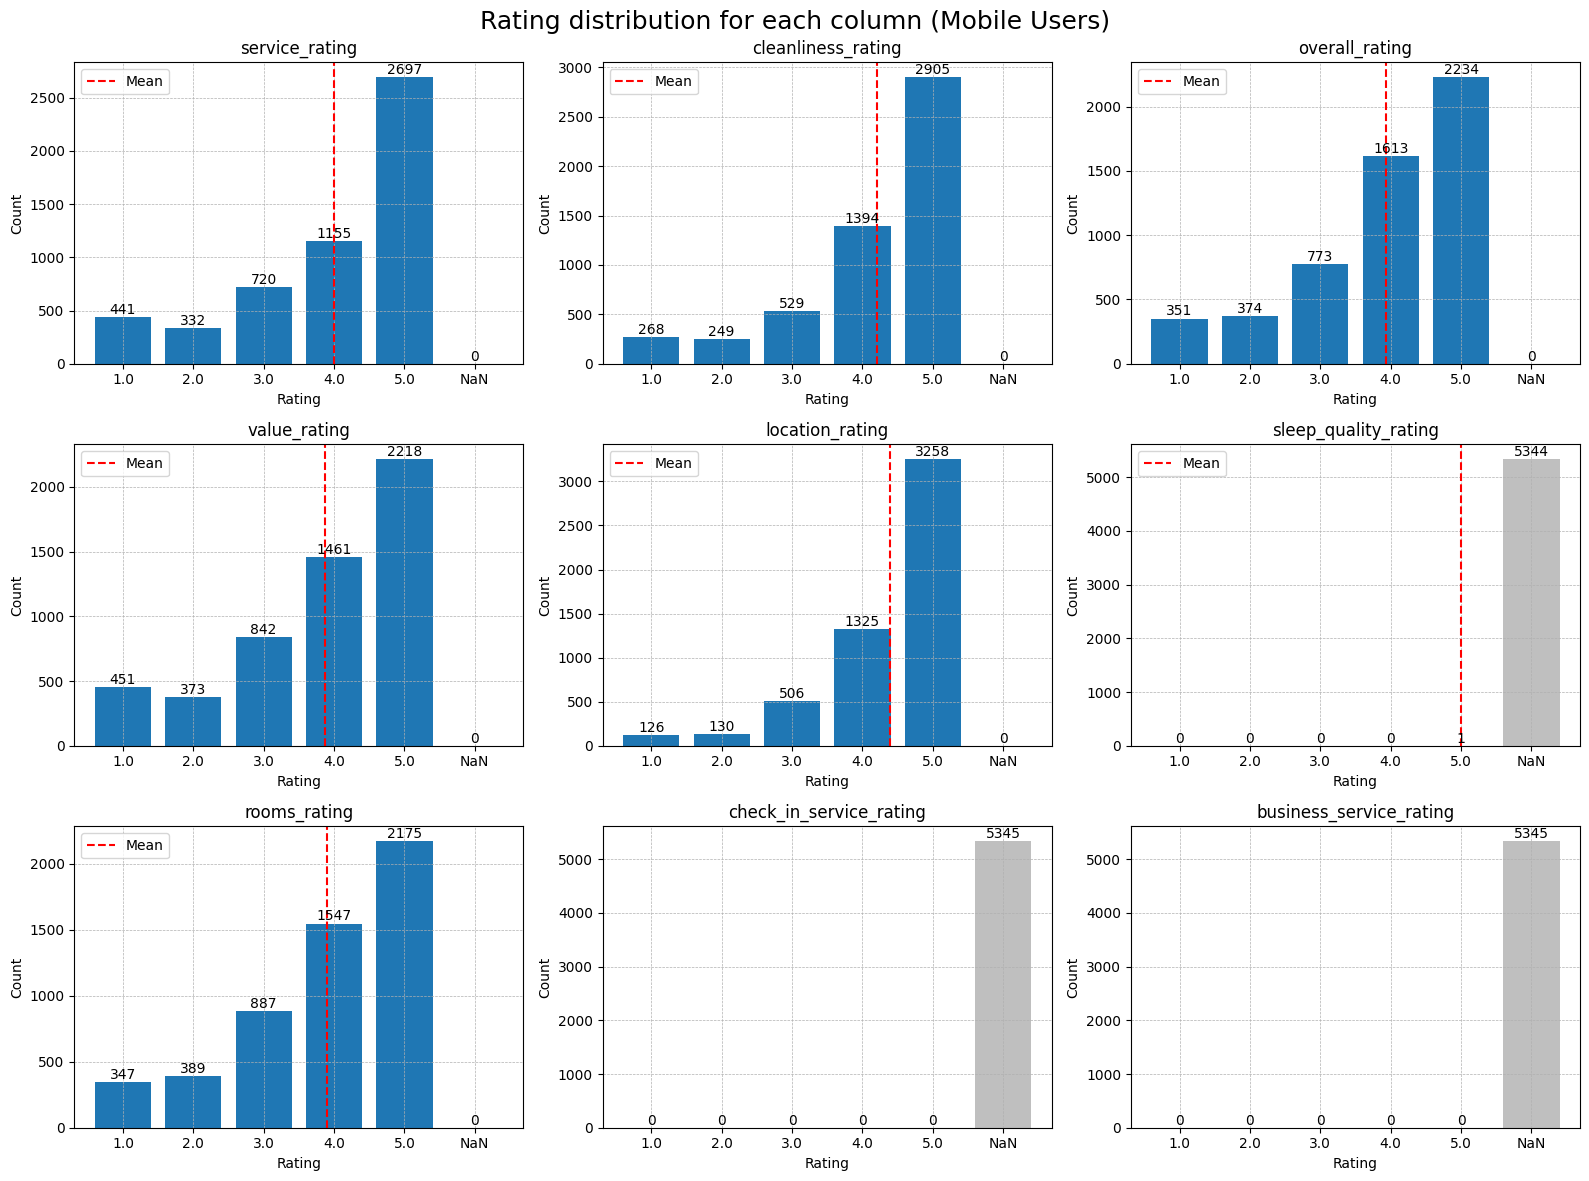

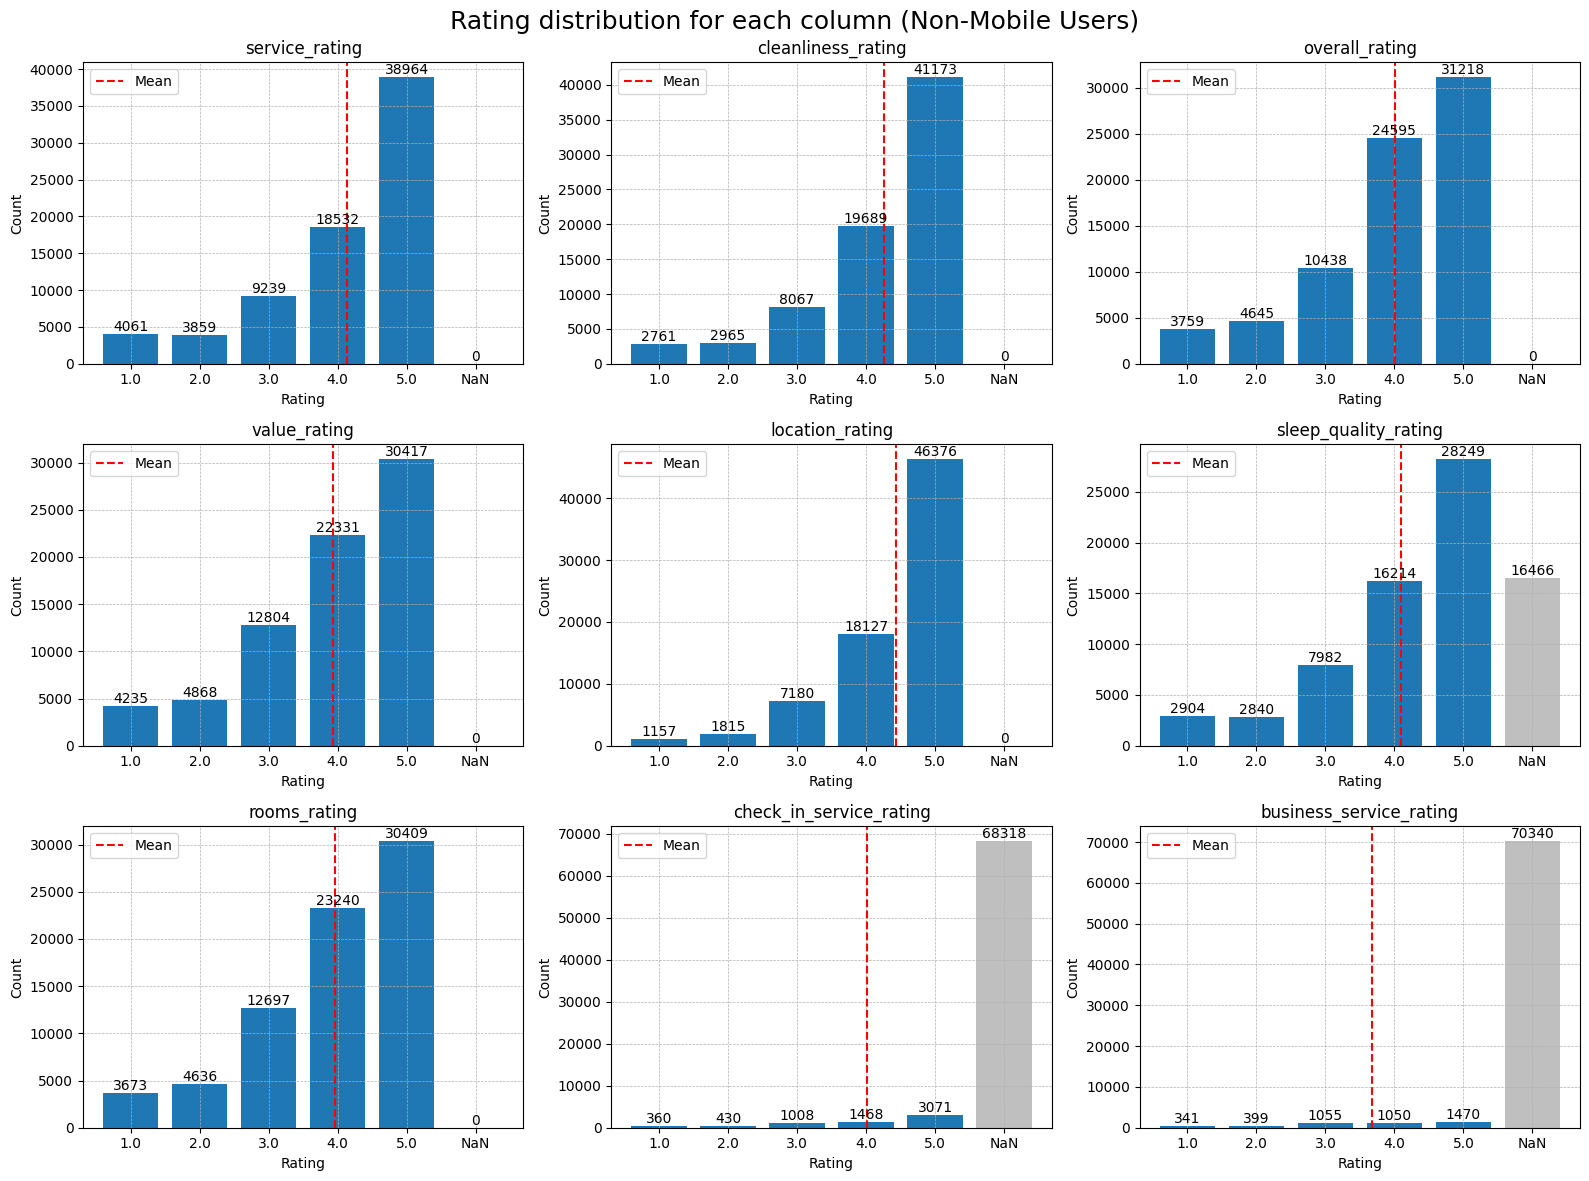

In [59]:
rating_column = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']

df_title = ['Mobile Users', 'Non-Mobile Users']
df_list = [mobile_df, non_mobile_df]

for title, df in zip(df_title, df_list):
    # Prepare subplot (3x3 for compactness)
    fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
    ax = ax.flatten()

    # Loop for each column
    for i, col in enumerate(rating_column):
        
        # Get the mean for vertical line
        mean = df[col].mean()
        
        # Replace NaN with string "NaN"
        df_filled = df[col].fillna('NaN').astype(str)
        
        # Do value_counts()
        counts = df_filled.value_counts()
        
        # Reindex so that we can show the NaN values as well
        counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
        colors = ['C0'] * 5 + ['gray']      # Set the color of the bar for each index
        
        # Plot the bar in the subplot
        bars = ax[i].bar(counts.index, counts.values, color=colors)
        
        # Add counts on top of each bar
        for bar in bars:
            height = bar.get_height()
            ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
        
        # Set the alpha of the NaN to semi-transparent
        bars[-1].set_alpha(0.5)
        
        # Only draw mean if numeric, ignore NaN
        if not np.isnan(mean):
            # Find position on x-axis
            mean_pos = mean - 1  # Subtract position by 1
            ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
            ax[i].legend()
            
        ax[i].set_title(f'{col}')
        ax[i].set_xlabel('Rating')
        ax[i].set_ylabel('Count')
        ax[i].grid(linestyle = '--', linewidth = 0.5)

    plt.suptitle(f'Rating distribution for each column ({title})', fontsize=18)
    plt.tight_layout()
    plt.show()

In [60]:
# Calculate mean
mobile_mean = mobile_df[rating_column].mean()
non_mobile_mean = non_mobile_df[rating_column].mean()

# Calculate difference
mean_diff = mobile_mean - non_mobile_mean

# Calculate difference percentage relatively to Non-Mobile Users
percent_diff = (mean_diff / non_mobile_mean) * 100

# Print each row
print(f"{'Rating Column':<30} | {'Non-Mobile Mean':>16} | {'Mobile Mean':>12} | {'Difference (%)':>12}")
print("-" * 80)
for col in rating_column:
    print(f"{col:<30} | {non_mobile_mean[col]:>16.3f} | {mobile_mean[col]:>12.3f} | {mean_diff[col]:>12.3f} ({percent_diff[col]:.2f}%)")
    
print(f'\nNumber of non-mobile users     : {len(non_mobile_df):,}')
print(f'Number of mobile users         : {len(mobile_df):,}')

Rating Column                  |  Non-Mobile Mean |  Mobile Mean | Difference (%)
--------------------------------------------------------------------------------
service_rating                 |            4.132 |        3.998 |       -0.133 (-3.23%)
cleanliness_rating             |            4.253 |        4.201 |       -0.052 (-1.23%)
overall_rating                 |            4.003 |        3.936 |       -0.066 (-1.66%)
value_rating                   |            3.935 |        3.865 |       -0.071 (-1.79%)
location_rating                |            4.430 |        4.396 |       -0.034 (-0.78%)
sleep_quality_rating           |            4.101 |        5.000 |        0.899 (21.92%)
rooms_rating                   |            3.965 |        3.901 |       -0.065 (-1.63%)
check_in_service_rating        |            4.019 |          nan |          nan (nan%)
business_service_rating        |            3.674 |          nan |          nan (nan%)

Number of non-mobile users     : 74,655

Key Observations:
* Users who fill the review via mobile tend to give lower rating. But, there are one thing to note which is the count of each user types. Non mobile users have almost 15x the number mobile users, with the tendencies of our users in giving out good ratings, then the number of bad ratings might be underrepresented because the drift in the rating percentage is on 1-3% which is very small. Even on sleep quality ratings, the count for mobile users is very very low which so it's completely biased to those low ratings.

#### **4.2.2. Does mobile users fill the review sooner?**

In [61]:
# Convert to numeric days
mobile_days = mobile_df['reviews_days_since_stay'].dt.days
non_mobile_days = non_mobile_df['reviews_days_since_stay'].dt.days

# Calculate mean
mobile_mean = mobile_days.mean()
non_mobile_mean = non_mobile_days.mean()

# Calculate difference
mean_diff = mobile_mean - non_mobile_mean

# Calculate difference percentage relatively to Non-Mobile Users
percent_diff = (mean_diff / non_mobile_mean) * 100

# Print each row
print(f"{'Rating Column':<30} | {'Non-Mobile Mean':>16} | {'Mobile Mean':>12} | {'Difference (%)':>12}")
print("-" * 80)
print(f"{'reviews_days_since_stay':<30} | {non_mobile_mean:>16.3f} | {mobile_mean:>12.3f} | {mean_diff:>12.3f} ({percent_diff:.2f}%)")
    
print(f'\nNumber of non-mobile users     : {len(non_mobile_df):,}')
print(f'Number of mobile users         : {len(mobile_df):,}')

Rating Column                  |  Non-Mobile Mean |  Mobile Mean | Difference (%)
--------------------------------------------------------------------------------
reviews_days_since_stay        |           24.013 |       20.772 |       -3.241 (-13.50%)

Number of non-mobile users     : 74,655
Number of mobile users         : 5,345


Key Observations:
* From this data alone, we can say that the Mobile users fill the review about 13.5% sooner than the Non-mobile Users.
* Although the number of users are different, but both dataframe has sufficient entries to approximate the time.
* Encouraging users to fill review with mobile can be a good starting point to have a sooner analytics of the hotel performance so that the hotel can adjust their strategy sooner than their competitors.

### **4.3. Top review Keywords for the hotels?**

My idea is to normalize the reviews, and check using tf-idf

In [62]:
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,31 days


The following method is referenced from this kaggle link https://www.kaggle.com/code/rowhitswami/keywords-extraction-using-tf-idf-method but is adjusted to our use case.

In [63]:
PUNCTUATION = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~“”‘’"""
TOP_K_KEYWORDS = 10
STOPWORD_PATH = "../src/stopwords.txt"

<>:1: SyntaxWarning: invalid escape sequence '\]'
<>:1: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_180938/4204542420.py:1: SyntaxWarning: invalid escape sequence '\]'
  PUNCTUATION = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~“”‘’"""


In [64]:
keyword_df = reviews_df.copy()
keyword_df = keyword_df[['hotel_id', 'title', 'text']]

In [65]:
from utils import (
    clean_text,
    get_stopwords_list,
    get_keywords,
)

# Remove the punctuation for both title and text
keyword_df['title'] = keyword_df['title'].apply(lambda x: clean_text(x, punctuation=PUNCTUATION))
keyword_df['text'] = keyword_df['text'].apply(lambda x: clean_text(x, punctuation=PUNCTUATION))

/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
# Checking the resul
keyword_df

,hotel_id,title,text
0,225108,daaaaaa bears,i recently stayed at w chicago lakeshore and o...
1,122005,would go back in a heartbeat location location...,we booked this hotel after out initial travel ...
2,939375,clean friendly affordable alternative to downtown,i am currently here in the hotel checking out ...
3,87573,atrium pool location and basic amenities were ...,two 10 yr olds enjoyed the large pool in the a...
4,123022,very good but nothing spectacular,stayed here on business because it was within ...
...,...,...,...
79995,1486034,oops not the best choice for me,the w boston should have been better for me bu...
79996,112412,my favorite hotel in seattle,the alexis is the best the service is always g...
79997,115644,good but to hot,this hotel needs aircon the rooms are to warm ...
79998,1549134,everything you would expect from a 4 star prop...,i had a late evening flight into houstons hobb...


In [67]:
# Convert into list
corpora_title = keyword_df['title'].to_list()
corpora_text = keyword_df['text'].to_list()

# Combine title and text as one big list of string
combined_corpora = [
    f"{title} {text}"
    for title, text in zip(corpora_title, corpora_text)
]

# Check first 5 result
combined_corpora[:5]

['daaaaaa bears i recently stayed at w chicago lakeshore and once again was impressted at how the staff went above and beyond to ensure i was well taken care of the location is fantastic and if youre lucky enough to get a lake view its even better we were in town for the bears texans games and having an amazing place to hang our hat made the trip that much easier i will stay there again and hopefully georgia is still working there shes awesome',
 'would go back in a heartbeat location location location and true ny style we booked this hotel after out initial travel plans to stay at another nyc hotel fell through and were we glad they did if you want a location that has everything on your doorstep creating the true in the movies feel then this is the hotel for you with madison sqaure garden on the same crossroads as the hotel and macys and the empire state building oe the same street just one block away you couldnt ask for better 10 minutes walk in the other direction will bring you to 

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

# load a set of stop words
stopwords=get_stopwords_list(STOPWORD_PATH)

# Initializing TF-IDF Vectorizer with stopwords
vectorizer = TfidfVectorizer(stop_words=stopwords, smooth_idf=True, use_idf=True)

# Creating vocab with our corpora
# Exlcluding first 10 docs for testing purpose
vectorizer.fit_transform(combined_corpora)

# Storing vocab
feature_names = vectorizer.get_feature_names_out()

/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['come', 'vis', 'viser', 'visest'] not in stop_words.
  warnings.warn(


In [69]:
result = []

# Print keywords for each corpora
for doc in combined_corpora:
    df = {}
    df['full_text'] = doc
    df['top_keywords'] = get_keywords(vectorizer, feature_names, doc, top_k_keywords=TOP_K_KEYWORDS)
    result.append(df)
    
# Save in a variable so we can use umap
final = pd.DataFrame(result)
final

,full_text,top_keywords
0,daaaaaa bears i recently stayed at w chicago l...,"[bears, impressted, daaaaaa, texans, georgia, ..."
1,would go back in a heartbeat location location...,"[effect, yorker, want, english, just, oe, harl..."
2,clean friendly affordable alternative to downt...,"[enjoyed, alternative, friendlyexcept, crinkel..."
3,atrium pool location and basic amenities were ...,"[atrium, pool, forms, olds, yr, beverage, plas..."
4,very good but nothing spectacular stayed here ...,"[taxi, ride, begins, 43, small, inclined, heav..."
...,...,...
79995,oops not the best choice for me the w boston s...,"[synthesize, mazelike, malloffice, wasnt, inde..."
79996,my favorite hotel in seattle the alexis is the...,"[alexis, seattle, favorite, awesome, visit, go..."
79997,good but to hot this hotel needs aircon the ro...,"[blockedthey, sleepthe, menuthe, retaurant, pa..."
79998,everything you would expect from a 4 star prop...,"[star, property, prepair, extream, lowball, ra..."


We got the keyword, although it will not be 100% accurate due to subs error or typos or user's mistake when writing reviews.

Number of unique words: 111820


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1108.68it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (50, 384)


/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embedding shape: (50, 2)
(50, 2)


/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hakhon/Documents/IS5128/IS512-Hotel-Analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

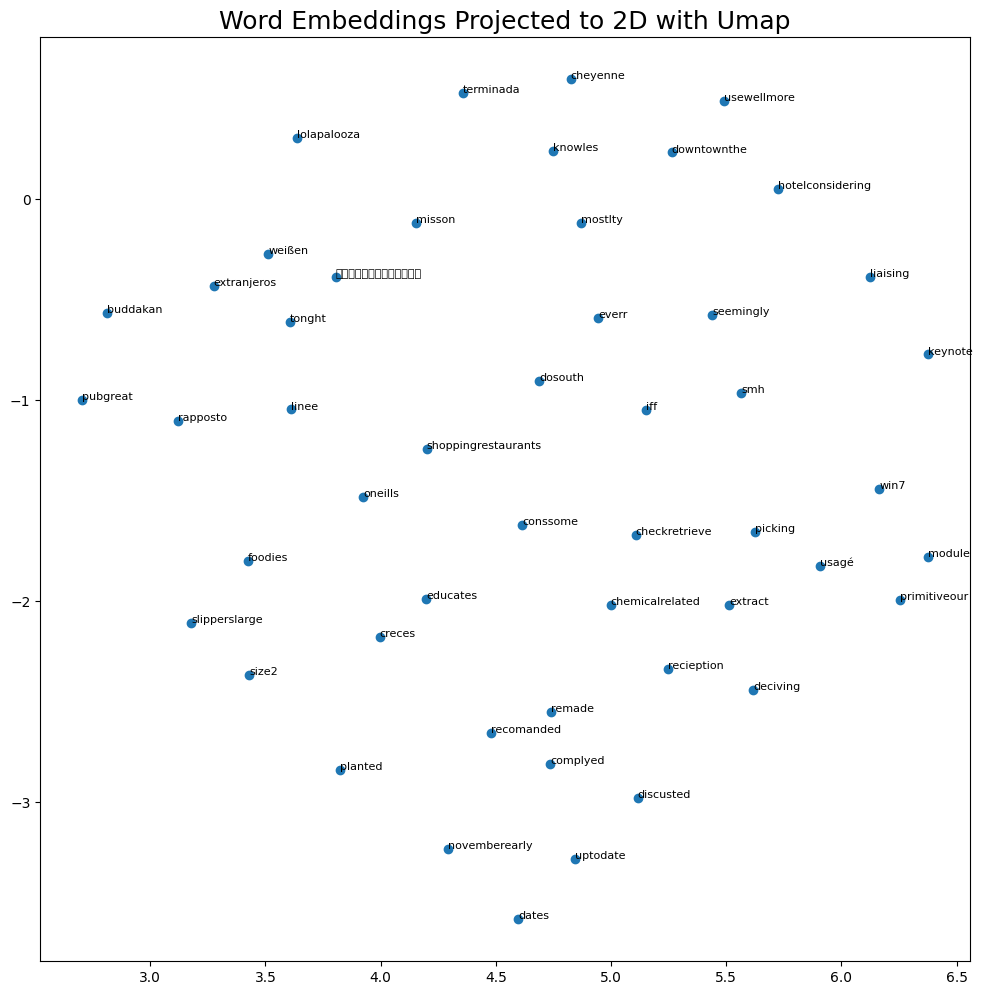

In [70]:
from utils import generate_keyword_embeddings_2d

embeddings_2d, selected_words = generate_keyword_embeddings_2d(
    final,
    n_words=50,         # Can be set to None to show all, but is not recommended
    random_state=42,    # Can be set to None
    model_name='all-MiniLM-L6-v2'
    )

# Show shape of embeddings
print(embeddings_2d.shape)

# Plot result
plt.figure(figsize=(12, 12))
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])

# Label the selected words by the embedding (might get cluttered)
for i, word in enumerate(selected_words):
    plt.text(embeddings_2d[i,0], embeddings_2d[i,1], word, fontsize=8)

plt.title("Word Embeddings Projected to 2D with Umap", fontsize=18)
plt.show()


The words seem random and contains a lot of misspelling. We will not be moving forward with this idea becaseu it is too much hassle to handle and we want to utilize the rating feature more. But this is our exploration step in understanding how review text can be used to extract information for semantic model.

Of course we can take an extra step in cleaning the text data with lemmatization method, but our group believe that using numerical rating data is more insightful for our goal of this assignments.


### **4.4. How is the Monthly Performance for 1 specific hotel?**

We can take a look at insight from 1 hotel specifically and see how it improves overtime throughout the year.

In [71]:
reviews_df['hotel_id'].value_counts()

hotel_id
214197     295
122005     273
93562      262
93618      258
93520      257
          ... 
635040       1
98032        1
95312        1
1515540      1
123318       1
Name: count, Length: 3380, dtype: int64

hotel_id of 214197 has the most reviews received, we can try map the stars from each month. For this purposes, it would be more accurate to use date_stayed_at instead of reviews_date because the user experience happened during their staying duration.

In [72]:
# The hotel id the we want to see the detail of
picked_hotel_id = "214197"

# Filter to that hotel only
curr_hotel_df = reviews_df[reviews_df['hotel_id'] == picked_hotel_id]
curr_hotel_df.head(3)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,reviews_days_since_stay
87,"“It was great, You get what you pay for, It is...",We were on the 10th floor and I was a bit conc...,2011-03-01,214197,0,2011-03-17,100536373,0,3.0,3.0,4.0,5.0,5.0,3.0,3.0,NaN,NaN,B1C488999358467553D8F9C9FFD125DF,16 days
104,"“location great, hotel dire”","we went for superior room,it was tiny, tired a...",2011-04-01,214197,1,2011-05-13,108051016,0,1.0,1.0,1.0,2.0,4.0,2.0,1.0,NaN,NaN,86522F9E773AEF2E29096322C81B97E7,42 days
239,"“Great Location, Horrible Room Conditions”","Don't believe the website, folks. The site mak...",2010-02-01,214197,1,2010-02-17,56307562,0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,NaN,NaN,9E6DF3EBE3A56B479C7AA7B03C6E2DD0,16 days


After filtering, let's group the data by month-year.

In [73]:
# Create month-year column
curr_hotel_df['month_year'] = curr_hotel_df['review_date'].dt.to_period('M')

rating_cols = ['service_rating','cleanliness_rating','overall_rating','value_rating','location_rating','sleep_quality_rating','rooms_rating','check_in_service_rating','business_service_rating']

# Group by month-year and calculate mean and count of ratings
monthly_summary = curr_hotel_df.groupby('month_year')[rating_cols].agg(['mean', 'count'])

monthly_summary.head()

/tmp/ipykernel_180938/3079150669.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_hotel_df['month_year'] = curr_hotel_df['review_date'].dt.to_period('M')


service_rating       cleanliness_rating       overall_rating        \
                     mean count               mean count           mean count   
month_year                                                                      
2008-01          1.000000     2           1.500000     2       1.500000     2   
2008-03          2.666667     3           2.666667     3       3.000000     3   
2008-05          1.500000     2           2.000000     2       2.500000     2   
2008-06          1.666667     3           1.666667     3       1.666667     3   
2008-08          2.000000     1           1.000000     1       1.000000     1   

           value_rating       location_rating       sleep_quality_rating  \
                   mean count            mean count                 mean   
month_year                                                                 
2008-01        2.000000     2        4.500000     2                  NaN   
2008-03        3.000000     3        4.666667     3                  NaN   
2008-05        2.000000     2        4.000000     2                  NaN   
2008-06        1.333333     3        3.333333     3                  NaN   
2008-08        1.000000     1        5.000000     1                  NaN   

                 rooms_rating       check_in_service_rating        \
           count         mean count                    mean count   
month_year                                                          
2008-01        0     1.000000     2                1.000000     2   
2008-03        0     2.000000     3                3.000000     3   
2008-05        0     2.000000     2                1.500000     2   
2008-06        0     1.666667     3                1.666667     3   
2008-08        0     1.000000     1                1.000000     1   

           business_service_rating        
                              mean count  
month_year                                
2008-01                        1.5     2  
2008-03                        2.0     1  
2008-05                        2.0     2  
2008-06                        2.0     2  
2008-08                        NaN     0

#### **Visualization**

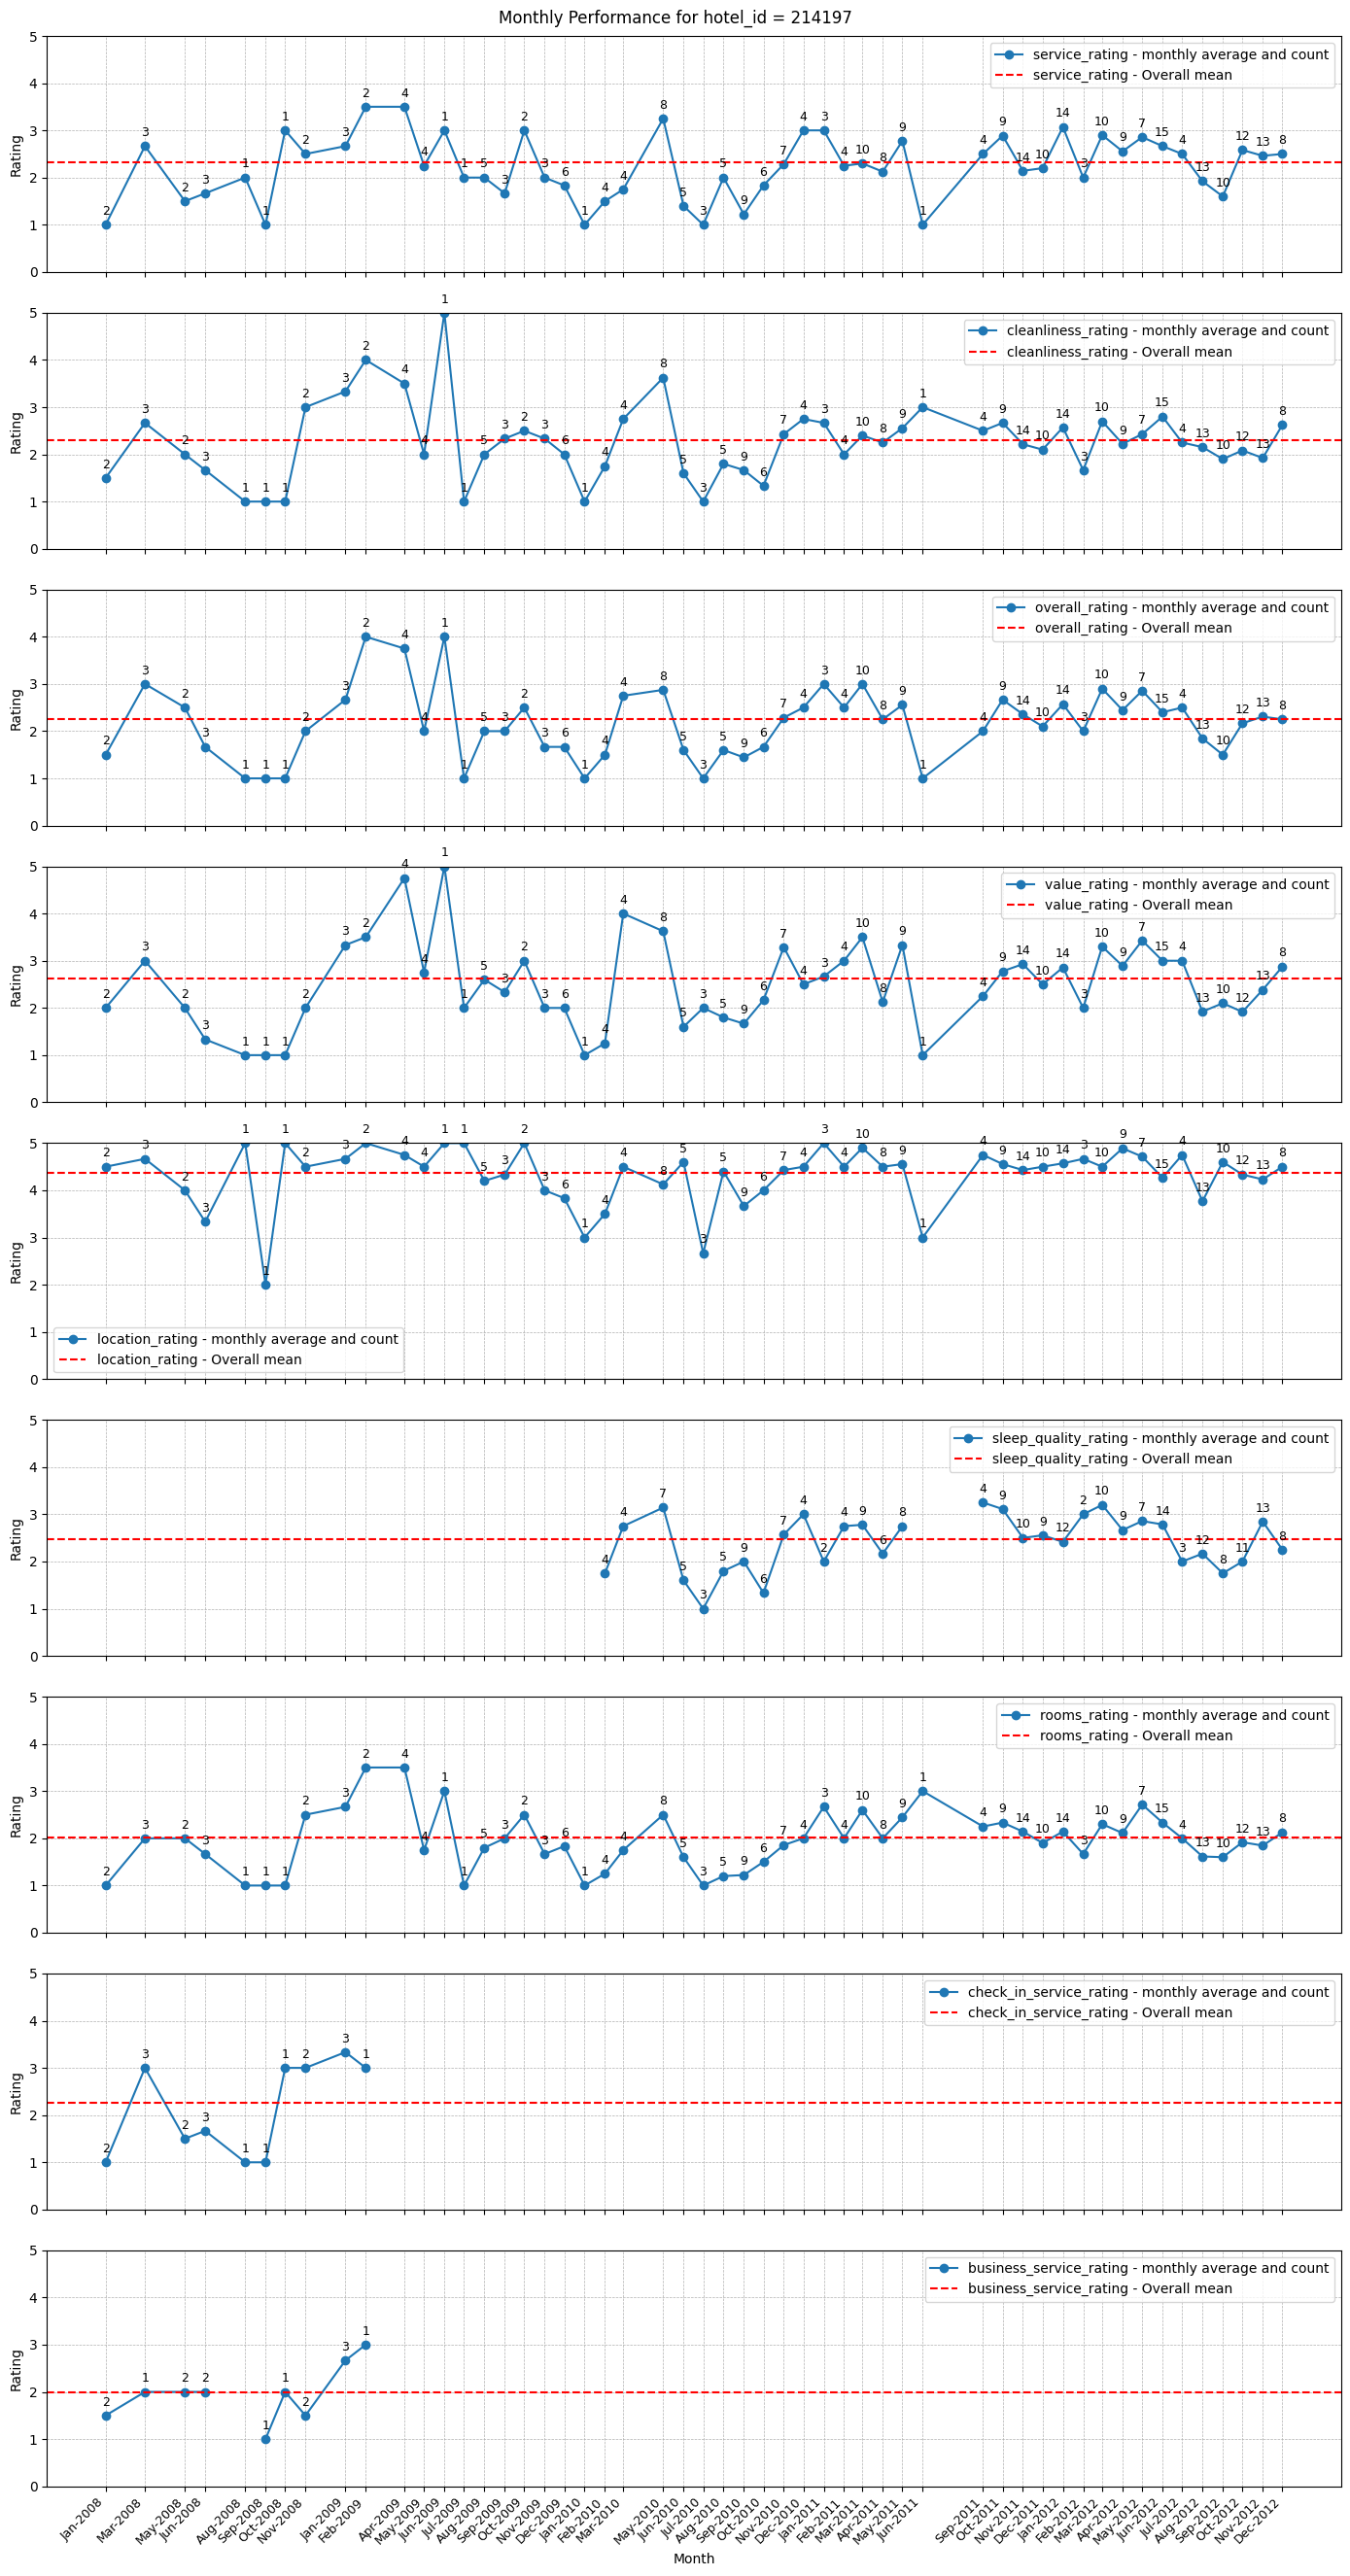

In [74]:
# Prepare subplots
fig, ax = plt.subplots(nrows=9, ncols=1, figsize=(14, 27), sharex=True)

for i, col in enumerate(rating_cols):
    # Select overall_rating mean and count
    curr_mean = monthly_summary[(col, 'mean')]
    curr_count = monthly_summary[(col, 'count')]
    
    # Count category mean for average horizontal line
    category_mean = curr_hotel_df[col].mean()

    # Convert index to timestamp for plotting
    curr_mean.index = curr_mean.index.to_timestamp()
    curr_count.index = curr_count.index.to_timestamp()
    
    # Plot the performance for each month
    ax[i].plot(curr_mean.index, curr_mean, marker='o', label=f'{col} - monthly average and count')
    
    # Show the count of reviews label on top of data points
    for x, y, count in zip(curr_mean.index, curr_mean, curr_count):
        ax[i].text(x, y + 0.15, str(int(count)), ha='center', va='bottom', fontsize=9)


    ax[i].axhline(category_mean, color='red', linestyle='--', label=f'{col} - Overall mean')
    ax[i].set_ylabel('Rating')
    ax[i].set_ylim(0, 5)
    ax[i].grid(linestyle = '--', linewidth = 0.5)
    ax[i].legend()
    
    ax[i].set_xticks(curr_mean.index)
    ax[i].set_xticklabels([x.strftime('%b-%Y') for x in curr_mean.index], rotation=45, ha='right', fontsize=9)

ax[-1].set_xlabel('Month')

plt.xticks(rotation=45)
plt.suptitle(f'Monthly Performance for hotel_id = {picked_hotel_id}')
plt.tight_layout()
plt.subplots_adjust(top=0.97)
plt.show()

This plot can be helpful for us to measure hotel's performance throughout the year and see how it grows. For hotel's side, they can find the best strategy to improve the rating by category and see the trend to look more specifically into data points that might cause the rating to go down, but this method relies heavily to the count of data points. With more data entries, better approximation about the actual performance can be obtained.

---

## 5. Archived Business Question

Archived Business Questions are a section to show how we wanted to tackle the problem in observing interesting ideas about the dataset, but due to the inavailability of the data or other reason, we put aside the question as it's not feasible.

### 5.1. How does the hotel rating differ by location?

This is not feasible because the location embeded in the dataset is the location of the user and not the hotel. It also contains a lot of wrong entries (Username saved as location). Using the location can actually mislead the prediction performance, so we scrape this idea.

### 5.2. which rating category contributes the most to the overall rating?

The overall rating has a high correlation to other features and it doesn't add up much information. Additionally, the dataset by TripAdvisor actually use 'Overall Rating' as one of the entry the user must fill when reviewing, meaning this should be treated as an independent variable instead of dependent. For this reason, this idea is left out.

### 5.3. best and worst service per location to tell which countries are better in certain category

The same issue persist on this case, we cannot produce the location of the hotel based on current available features. However, the part that shows the best and worst performers are already in the previous section.

### 5.4. Is mobile reviews shorter and less helpful?

Although this part is pretty feasible, but after our observations of the review text data. The information will not be useful due to certain factors. There are some other considerations like deciding the optimal text length for long and short text which can subjectively affect the observations, so this business question is not our main concern.

### 5.5. Do fast reviews tend to be more negative?

The same issue with question 5.4. Fast and Slow review is subjective and depends on the window size that we set. Considering the skewness of our data, the amount of positive review will hide the findings from negative reviews, unless we analyze only on negative finding. But out goal here is to display the hotel performance and trends and not the author. So we scrape this idea.

### 5.6. are experienced travelers more critical than casual reviewers?

With the same reason, our concern is more on the hotel performance, so we will not spend too much time understanding our unique users, plus the entry of author with large num of reviews are very small, which makes it hard to analyze.

---

### Close connection

In [75]:
conn.close()